### JRCLUST: Bundled vs Linear 

In [1]:
from extract_data import *
import matplotlib.pyplot as plt
from compare_data import * 
import numpy as np
import bombcell as bc

✅ ipywidgets available - interactive GUI ready


In [2]:
# load data that will be used throughout the notebook 
linear_prm_path = r"E:\Viktor_08_sortings\linear_5_5_JRCLUST\linear_5_5_amp.prm"
siteLoc_linear, siteMap_linear, sampleRate_linear = get_prm_info(linear_prm_path)
linear_res_mat_path = r"E:\Viktor_08_sortings\linear_5_5_JRCLUST\linear_5_5_amp_res.mat"
linear_spikesFilt_path = r"E:\Viktor_08_sortings\linear_5_5_JRCLUST\linear_5_5_spikesFilt.mat"


bundled_prm_path = r"E:\Viktor_08_sortings\bundled_5_5_JRCLUST\bundled_5_5_amp.prm"
siteLoc_bundled, siteMap_bundled, sampleRate_bundled = get_prm_info(bundled_prm_path)
bundled_res_mat_path = r"E:\Viktor_08_sortings\bundled_5_5_JRCLUST\bundled_5_5_amp_res.mat"
bundled_spikesFilt_path = r"E:\Viktor_08_sortings\bundled_5_5_JRCLUST\bundled_5_5_spikesFilt.mat"

***
### Determine which units and spikes could be potential matches between the two probe types 

In [3]:
b_cluster_data =  extract_cluster_data_JRCLUST(bundled_res_mat_path, siteMap_bundled)
print(f"JRCLUST bundled units ({len(b_cluster_data[0])}): {b_cluster_data[0]}")

l_cluster_data = extract_cluster_data_JRCLUST(linear_res_mat_path, siteMap_linear)
print(f"JRCLUST linear units ({len(l_cluster_data[0])}): {l_cluster_data[0]}")

Total spike num: (1, 726205)
JRCLUST bundled units (45): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
Total spike num: (1, 722054)
JRCLUST linear units (39): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


In [4]:
print(f"{726205 - 722054} more spikes were found when the bundled geom than with the linear geom")

print("Let's first see which spikes are the same between the two geometries (including a tolerance).")

4151 more spikes were found when the bundled geom than with the linear geom
Let's first see which spikes are the same between the two geometries (including a tolerance).


In [5]:
d = []

for res_p in [bundled_res_mat_path, linear_res_mat_path]:
    res_file = Path(res_p)

    with h5py.File(res_file, "r") as f:
        d.append(f["spikeTimes"][...].squeeze() - 1)

print("Some of these spikes can be duplicates")
unique_b_spike_samples = np.unique(d[0])
unique_l_spike_samples = np.unique(d[1])

print(f"unique b spike num: {len(unique_b_spike_samples)}. {726205 - len(unique_b_spike_samples)} non-unique spikes.\nunique l spike num: {len(unique_l_spike_samples)}. {722054 - len(unique_l_spike_samples)} non-unique spikes.")


Some of these spikes can be duplicates
unique b spike num: 724210. 1995 non-unique spikes.
unique l spike num: 720460. 1594 non-unique spikes.


In [6]:
matches = identical_spikes(d[0], d[1], tol=0)
print(f"With a tolerance of 0 samples, {matches.shape[0]} spikes times were found to be identical.")

print(f"This is the same number of spikes as found in total with the linear geometry.")

print("We can now compare the cluster_id, location, peak_channel, and waveform differences between 'matching' and 'non-matching' spikes")

With a tolerance of 0 samples, 722054 spikes times were found to be identical.
This is the same number of spikes as found in total with the linear geometry.
We can now compare the cluster_id, location, peak_channel, and waveform differences between 'matching' and 'non-matching' spikes


We'll start by looking into the non-matched spikes to see in what ways they are different from those that are matched

399 of the 4151 spikes are not present in the linear spike times


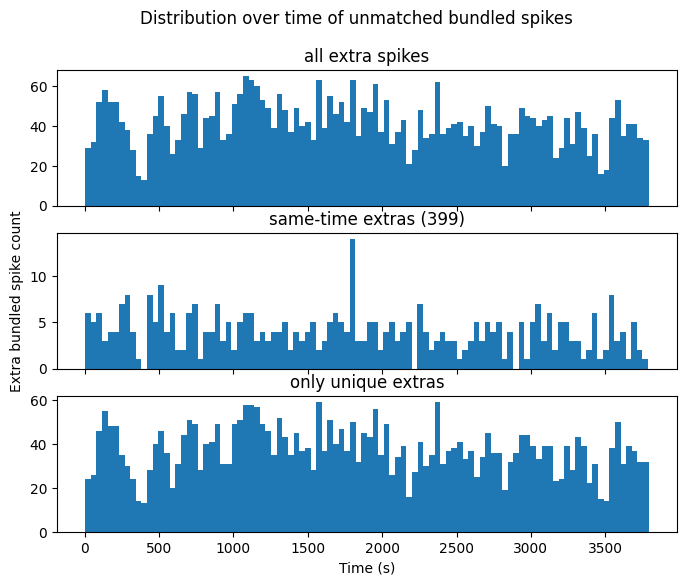

In [7]:
b_spikes = d[0]
l_spikes = d[1]

bundled_match_idx = matches[:,0]
linear_match_idx = matches[:,1]

bundled_mask = np.ones(len(b_spikes), dtype=bool)
bundled_mask[bundled_match_idx] = False

unmatched_samples = b_spikes[bundled_mask]
print(f"{np.sum(np.isin(unmatched_samples, l_spikes))} of the {len(unmatched_samples)} spikes are not present in the linear spike times")

fs = 20000
# where do the unmatched samples occur in the recording 
all_unmatched_seconds = unmatched_samples / fs
same_time_extras = unmatched_samples[np.isin(unmatched_samples, l_spikes)] / fs 
new_time_extras = unmatched_samples[~np.isin(unmatched_samples, l_spikes)] / fs 


fig, axes = plt.subplots(3,1 , figsize=(8,6), sharex=True)
axes[0].hist(all_unmatched_seconds, bins=100)
axes[0].set_title("all extra spikes")
axes[1].hist(same_time_extras, bins=100)
axes[1].set_title("same-time extras (399)")
axes[2].hist(new_time_extras, bins=100)
axes[2].set_title("only unique extras")
plt.xlabel("Time (s)")
axes[1].set_ylabel("Extra bundled spike count")
plt.suptitle(f"Distribution over time of unmatched bundled spikes")
plt.show()

We see that the unmatched spikes are rather uniformly distributed suggesting that they are not due to startup effects, drift, or other state-dependent effects.

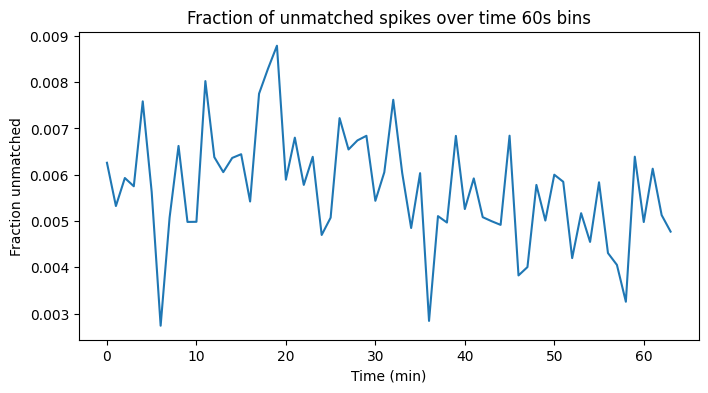

In [8]:
bin_size_sec = 60

bins = np.arange(
    0,
    b_spikes.max()/fs + bin_size_sec,
    bin_size_sec
)

unmatched_counts, _ = np.histogram(
    all_unmatched_seconds,
    bins=bins
)

all_counts, _ = np.histogram(
    b_spikes/fs,
    bins=bins
)

fraction = unmatched_counts / all_counts

plt.figure(figsize=(8,4))
plt.plot(bins[:-1]/60, fraction)
plt.title("Fraction of unmatched spikes over time 60s bins")
plt.xlabel("Time (min)")
plt.ylabel("Fraction unmatched")
plt.show()

Are these unmatched spikes almost duplicates ? 
We already know 399 spikes are identical to spikes already existing but what about the 3752 others? 

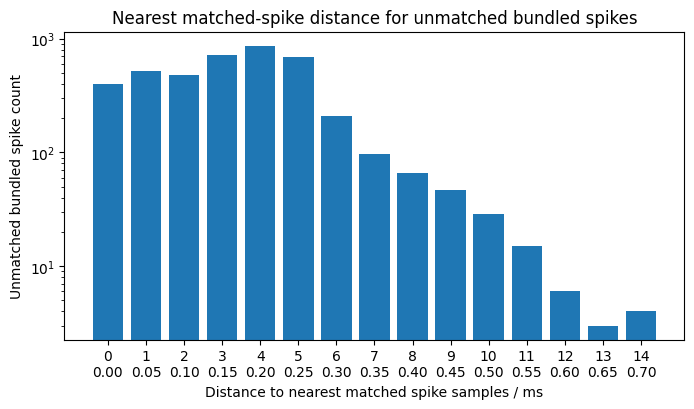

Unique nearest sample distances: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [9]:
fs =20000

matched_times = np.sort(b_spikes[bundled_match_idx])
unmatched_samples = np.sort(unmatched_samples)

idx = np.searchsorted(matched_times, unmatched_samples)

left = np.maximum(idx - 1, 0)
right = np.minimum(idx, len(matched_times) - 1)

nearest_dist = np.minimum(
    np.abs(unmatched_samples - matched_times[left]),
    np.abs(unmatched_samples - matched_times[right])
)

counts = np.bincount(nearest_dist)
distances = np.arange(len(counts))

plt.figure(figsize=(8, 4))
plt.bar(distances, counts)
plt.yscale("log")
plt.xticks(distances)
plt.xlabel("Distance to nearest matched spike samples / ms")
plt.xticks(distances, [f"{d}\n{d/fs*1000:.2f}" for d in distances])
plt.ylabel("Unmatched bundled spike count")
plt.title("Nearest matched-spike distance for unmatched bundled spikes")
plt.show()


print(f"Unique nearest sample distances: {np.unique(nearest_dist)}")



In [10]:
fs = 20_000
near_thresh = 5

n_total = len(nearest_dist)
n_same_time = np.sum(nearest_dist == 0)
n_near = np.sum(nearest_dist <= near_thresh)
n_far = np.sum(nearest_dist > near_thresh)

print(f"Total unmatched bundled spikes: {n_total}")
print(f"Same-sample extras: {n_same_time} ({n_same_time/n_total:.2%})")
print(f"Within ±{near_thresh} samples ({near_thresh/fs*1000:.2f} ms): {n_near} ({n_near/n_total:.2%})")
print(f"> {near_thresh} samples: {n_far} ({n_far/n_total:.2%})")

for thresh in [1, 5, 10]:
    n = np.sum(nearest_dist <= thresh)
    print(f"≤ {thresh} samples ({thresh/fs*1000:.2f} ms): {n} / {n_total} = {n/n_total:.2%}")

Total unmatched bundled spikes: 4151
Same-sample extras: 399 (9.61%)
Within ±5 samples (0.25 ms): 3676 (88.56%)
> 5 samples: 475 (11.44%)
≤ 1 samples (0.05 ms): 919 / 4151 = 22.14%
≤ 5 samples (0.25 ms): 3676 / 4151 = 88.56%
≤ 10 samples (0.50 ms): 4123 / 4151 = 99.33%


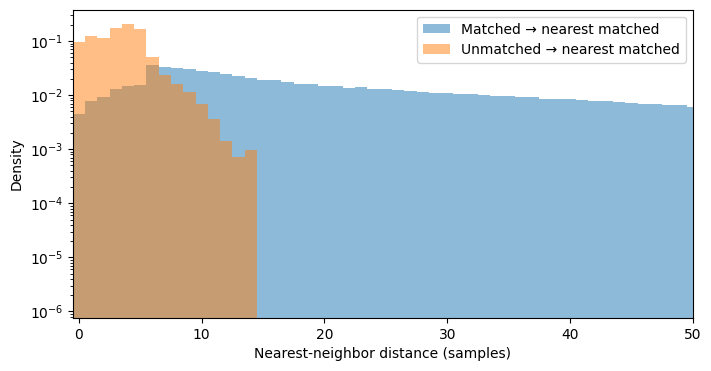

In [11]:
def nearest_neighbor_dist_same_array(times):
    times = np.sort(np.asarray(times))
    prev_dist = np.r_[np.inf, np.diff(times)]
    next_dist = np.r_[np.diff(times), np.inf]
    return np.minimum(prev_dist, next_dist)

matched_times = np.sort(b_spikes[bundled_match_idx])
matched_nn_dist = nearest_neighbor_dist_same_array(matched_times)

plt.figure(figsize=(8, 4))

bins = np.arange(0, max(nearest_dist.max(), matched_nn_dist.max()) + 2) - 0.5

plt.hist(
    matched_nn_dist,
    bins=bins,
    alpha=0.5,
    density=True,
    label="Matched → nearest matched"
)

plt.hist(
    nearest_dist,
    bins=bins,
    alpha=0.5,
    density=True,
    label="Unmatched → nearest matched"
)

plt.xlim(-0.5, 50)
plt.yscale("log")
plt.xlabel("Nearest-neighbor distance (samples)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [12]:
for thresh in [1, 5, 10]:
    p_unmatched = np.mean(nearest_dist <= thresh)
    p_matched = np.mean(matched_nn_dist <= thresh)

    print(
        f"≤ {thresh} samples: "
        f"unmatched={p_unmatched:.2%}, "
        f"matched baseline={p_matched:.2%}, "
        f"ratio={p_unmatched / p_matched:.2f}x"
    )

≤ 1 samples: unmatched=22.14%, matched baseline=1.23%, ratio=17.94x
≤ 5 samples: unmatched=88.56%, matched baseline=6.50%, ratio=13.63x
≤ 10 samples: unmatched=99.33%, matched baseline=22.51%, ratio=4.41x


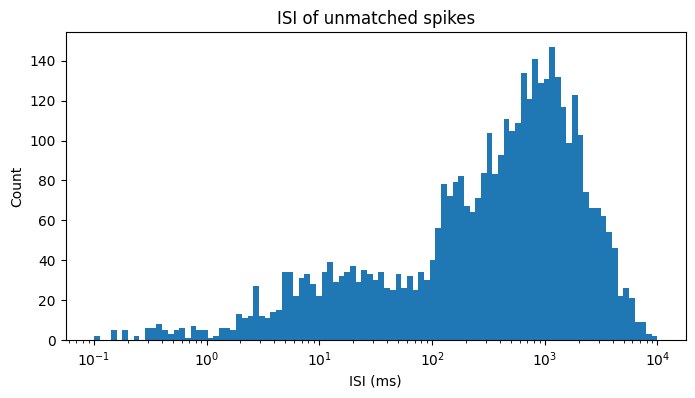

In [13]:
isi = np.diff(unmatched_samples) / fs * 1000 # in ms 

plt.figure(figsize=(8,4))
plt.hist(isi, bins=np.logspace(-1,4,100))
plt.title("ISI of unmatched spikes")
plt.xscale("log")
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.show()

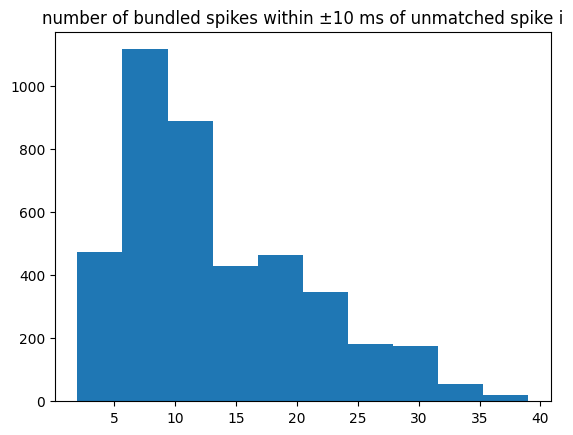

In [14]:
window = int(0.01 * fs)  # 10 ms

left = np.searchsorted(
    b_spikes,
    unmatched_samples - window
)

right = np.searchsorted(
    b_spikes,
    unmatched_samples + window
)

local_density = right - left

plt.figure()
plt.hist(local_density)
plt.title("number of bundled spikes within ±10 ms of unmatched spike i")
plt.show()

Are there amplitude differences between the matched and unmatched spikes?

(1, 722054)
(1, 4151)


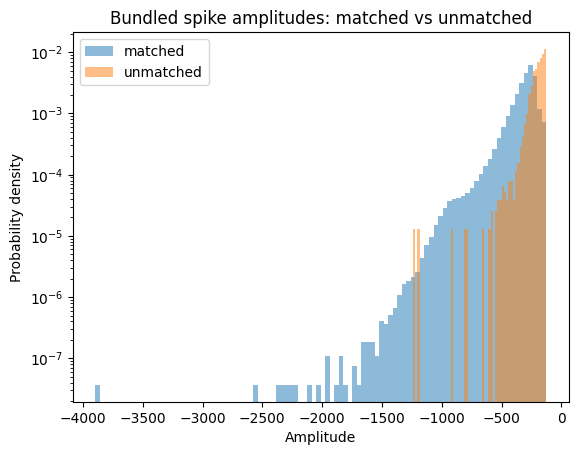

In [15]:
a = []

for res_p in [bundled_res_mat_path, linear_res_mat_path]:
    res_file = Path(res_p)

    with h5py.File(res_file, "r") as f:
        a.append(f["spikeAmps"][...].squeeze())

b_amps = a[0]
bundled_mask = np.ones(len(b_amps), dtype=bool)
bundled_mask[bundled_match_idx] = False

unmatched_samples = b_spikes[bundled_mask]
bundled_matched_spike_amps = np.array([b_amps[~bundled_mask]])
print(bundled_matched_spike_amps.shape)
bundled_unmatched_spike_amps = np.array([b_amps[bundled_mask]])
print(bundled_unmatched_spike_amps.shape)


plt.figure()
plt.hist(bundled_matched_spike_amps.ravel(), bins=100, density=True, alpha=0.5, label="matched")

plt.hist(bundled_unmatched_spike_amps.ravel(), bins=60, density=True, alpha=0.5, label="unmatched")
plt.yscale("log")
plt.title("Bundled spike amplitudes: matched vs unmatched")
plt.legend()
plt.xlabel("Amplitude")
plt.ylabel("Probability density")
plt.show()


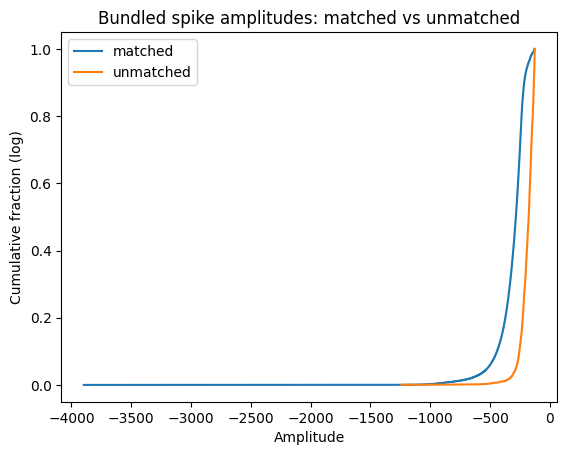

In [16]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf_m = ECDF(bundled_matched_spike_amps.ravel())
ecdf_u = ECDF(bundled_unmatched_spike_amps.ravel())

plt.figure()

plt.plot(ecdf_m.x, ecdf_m.y, label="matched")
plt.plot(ecdf_u.x, ecdf_u.y, label="unmatched")

plt.xlabel("Amplitude")
plt.ylabel("Cumulative fraction (log)")
plt.title("Bundled spike amplitudes: matched vs unmatched")
plt.legend()
plt.show()

In [17]:
for name, amps in {
    "matched": bundled_matched_spike_amps.ravel(),
    "unmatched": bundled_unmatched_spike_amps.ravel(),
}.items():

    print(name)
    print("median", np.median(amps))
    print("mean", np.mean(amps))
    print("5th", np.percentile(amps,5))
    print("95th", np.percentile(amps,95))
    print()

matched
median -285.0
mean -313.644048783055
5th -521.0
95th -187.0

unmatched
median -178.0
mean -191.03637677668033
5th -284.0
95th -130.0



From the above results, it's clear that detection of large amplitude spikes are detected by both geometries. The bundled geometry unique spikes that have no linear match, tend to be smaller in amplitude. 

***

## cluster analysis

In [18]:
spike_clusters = []
cluster_sites = []

for res_p in [bundled_res_mat_path, linear_res_mat_path]:
    res_file = Path(res_p)

    with h5py.File(res_file, "r") as f:
        sc = f["spikeClusters"][...].squeeze().ravel().astype(np.int32) # ignore sites with index -1 and 0 ? 
        spike_clusters.append(sc)

        cs = f["clusterSites"][...].squeeze().ravel().astype("int32")
        cluster_sites.append(cs)

In [19]:
import numpy as np
import pandas as pd

def compare_cluster_assignments(
    clusters_A,
    clusters_B,
    matches,
    n_spikes_A=None,
    n_spikes_B=None,
    name_A="bundled",
    name_B="linear",
):
    clusters_A = np.asarray(clusters_A)
    clusters_B = np.asarray(clusters_B)
    matches = np.asarray(matches, dtype=int)

    if n_spikes_A is None:
        n_spikes_A = len(clusters_A)
    if n_spikes_B is None:
        n_spikes_B = len(clusters_B)

    idx_A = matches[:, 0]
    idx_B = matches[:, 1]

    matched_clusters_A = clusters_A[idx_A]
    matched_clusters_B = clusters_B[idx_B]


    # matched spike-level table
    matched_df = pd.DataFrame({
        f"{name_A}_spike_idx": idx_A,
        f"{name_B}_spike_idx": idx_B,
        f"{name_A}_cluster": matched_clusters_A,
        f"{name_B}_cluster": matched_clusters_B,
    })
    
    # -----------------------------
    # 2. Cluster overlap table # counts how many matched spikes fall into each (A cluster, B cluster) pair
    # -----------------------------
    overlap = (
        matched_df
        .groupby([f"{name_A}_cluster", f"{name_B}_cluster"])
        .size()
        .reset_index(name="n_shared_spikes")
        .sort_values("n_shared_spikes", ascending=False)
        .reset_index(drop=True)
    )

    # total matched spikes per cluster
    total_A = matched_df[f"{name_A}_cluster"].value_counts()
    total_B = matched_df[f"{name_B}_cluster"].value_counts()

    overlap[f"{name_A}_matched_total"] = overlap[f"{name_A}_cluster"].map(total_A)
    overlap[f"{name_B}_matched_total"] = overlap[f"{name_B}_cluster"].map(total_B)

    overlap[f"frac_of_{name_A}"] = (
        overlap["n_shared_spikes"] / overlap[f"{name_A}_matched_total"]
    )
    overlap[f"frac_of_{name_B}"] = (
        overlap["n_shared_spikes"] / overlap[f"{name_B}_matched_total"]
    )

    # -----------------------------
    # 3. Best cluster mapping
    #    A -> B by maximum shared spikes. ie for each A cluster, pick the B cluster with the largest overlap 
    # many A clusters can map to the same B cluster (good for detecting merges)
    # -----------------------------
    best_A_to_B = (
        overlap
        .sort_values("n_shared_spikes", ascending=False)
        .drop_duplicates(f"{name_A}_cluster")
        .reset_index(drop=True)
    )

    A_to_B = dict(zip(
        best_A_to_B[f"{name_A}_cluster"],
        best_A_to_B[f"{name_B}_cluster"],
    ))

    # also B -> A, useful for checking merges/splits
    best_B_to_A = (
        overlap
        .sort_values("n_shared_spikes", ascending=False)
        .drop_duplicates(f"{name_B}_cluster")
        .reset_index(drop=True)
    )

    B_to_A = dict(zip(
        best_B_to_A[f"{name_B}_cluster"],
        best_B_to_A[f"{name_A}_cluster"],
    ))

    # -----------------------------
    # 4. Classify matched spikes
    # -----------------------------
    expected_B = np.array([A_to_B[a] for a in matched_clusters_A])

    matched_df[f"expected_{name_B}_cluster"] = expected_B
    matched_df["same_mapped_unit"] = matched_clusters_B == expected_B

    reassigned_matched = matched_df[~matched_df["same_mapped_unit"]]

    reassigned_summary = (
        reassigned_matched
        .groupby([
            f"{name_A}_cluster",
            f"expected_{name_B}_cluster",
            f"{name_B}_cluster",
        ])
        .size()
        .reset_index(name="n_reassigned_matched_spikes")
        .sort_values("n_reassigned_matched_spikes", ascending=False)
        .reset_index(drop=True)
    )

    # -----------------------------
    # 5. Unmatched spikes in A and B
    # -----------------------------
    unmatched_A_mask = np.ones(len(clusters_A), dtype=bool)
    unmatched_B_mask = np.ones(len(clusters_B), dtype=bool)

    unmatched_A_mask[idx_A] = False
    unmatched_B_mask[idx_B] = False

    unmatched_A_clusters = clusters_A[unmatched_A_mask]
    unmatched_B_clusters = clusters_B[unmatched_B_mask]

    unmatched_A_counts = (
        pd.Series(unmatched_A_clusters)
        .value_counts()
        .rename_axis(f"{name_A}_cluster")
        .reset_index(name=f"n_unmatched_{name_A}_spikes")
    )

    unmatched_B_counts = (
        pd.Series(unmatched_B_clusters)
        .value_counts()
        .rename_axis(f"{name_B}_cluster")
        .reset_index(name=f"n_unmatched_{name_B}_spikes")
    )

    # Attach expected partner cluster to unmatched A spikes
    unmatched_A_counts[f"mapped_{name_B}_cluster"] = (
        unmatched_A_counts[f"{name_A}_cluster"].map(A_to_B)
    )

    # -----------------------------
    # 6. Split / merge diagnostics
    # -----------------------------
    n_B_per_A = (
        overlap
        .groupby(f"{name_A}_cluster")[f"{name_B}_cluster"]
        .nunique()
        .reset_index(name=f"n_{name_B}_clusters_receiving_spikes")
    )

    n_A_per_B = (
        overlap
        .groupby(f"{name_B}_cluster")[f"{name_A}_cluster"]
        .nunique()
        .reset_index(name=f"n_{name_A}_clusters_contributing_spikes")
    )

    summary = {
        "n_matched_spikes": len(matches),
        f"n_unmatched_{name_A}_spikes": int(unmatched_A_mask.sum()),
        f"n_unmatched_{name_B}_spikes": int(unmatched_B_mask.sum()),
        "n_same_mapped_unit": int(matched_df["same_mapped_unit"].sum()),
        "frac_same_mapped_unit": float(matched_df["same_mapped_unit"].mean()),
        "n_reassigned_matched_spikes": int((~matched_df["same_mapped_unit"]).sum()),
        "frac_reassigned_matched_spikes": float((~matched_df["same_mapped_unit"]).mean()),
    }

    return {
        "summary": summary,
        "matched_spikes": matched_df,
        "overlap": overlap,
        "best_A_to_B": best_A_to_B,
        "best_B_to_A": best_B_to_A,
        "reassigned_matched": reassigned_summary,
        f"unmatched_{name_A}_counts": unmatched_A_counts,
        f"unmatched_{name_B}_counts": unmatched_B_counts,
        "split_diagnostics": n_B_per_A,
        "merge_diagnostics": n_A_per_B,
        f"unmatched_{name_A}_mask": unmatched_A_mask,
        f"unmatched_{name_B}_mask": unmatched_B_mask,
    }

res = compare_cluster_assignments(
    clusters_A=spike_clusters[0],
    clusters_B=spike_clusters[1],
    matches=matches,
    name_A="bundled",
    name_B="linear")


#res["best_B_to_A"] # shows the best cluster matches with repeats in B and not A 
#res['reassigned_matched'].head(20) # Shows matched spikes that belong to a bundled cluster but were assigned to a non-equivalent linear cluster
#res["unmatched_bundled_counts"] # shows which bundled clusters contain extra bundled-only spikes
#res["summary"]["frac_same_mapped_unit"] # of spikes that matched in time, what fraction were assigned to the corresponding unit across time

res["summary"]


{'n_matched_spikes': 722054,
 'n_unmatched_bundled_spikes': 4151,
 'n_unmatched_linear_spikes': 0,
 'n_same_mapped_unit': 622260,
 'frac_same_mapped_unit': 0.8617915003586989,
 'n_reassigned_matched_spikes': 99794,
 'frac_reassigned_matched_spikes': 0.13820849964130105}

We can start by visually analyzing where the different clusters are located on each probe geometry. Each cluster is first plotted by peak channel. 

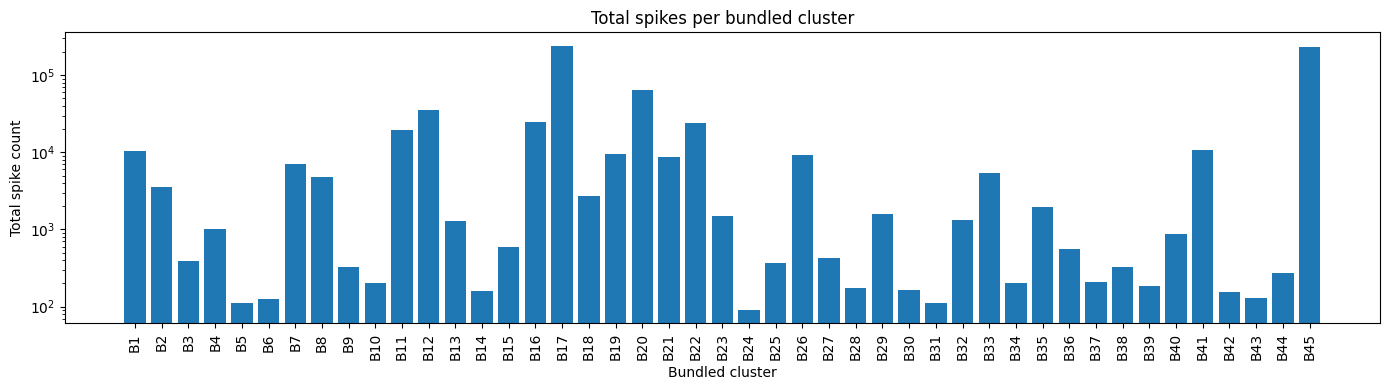

90 242544


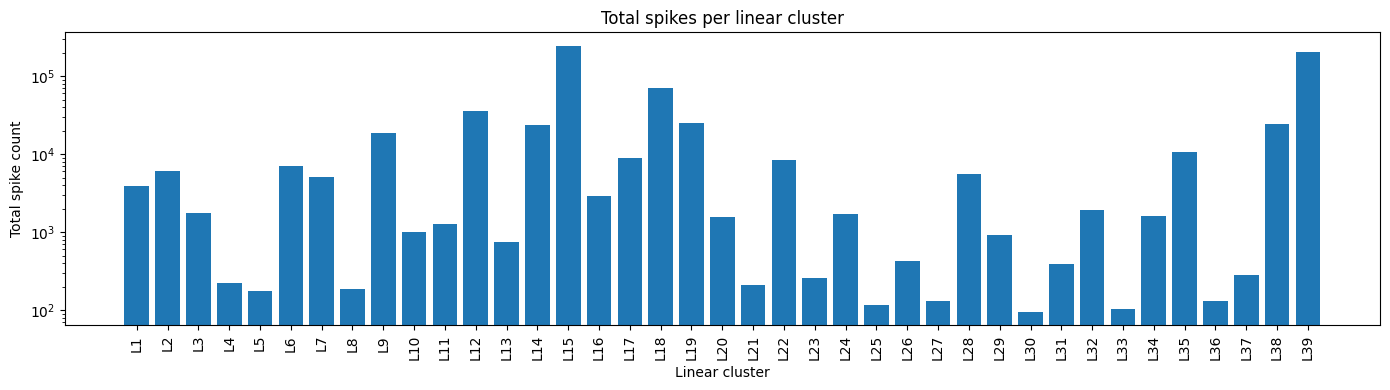

95 245200


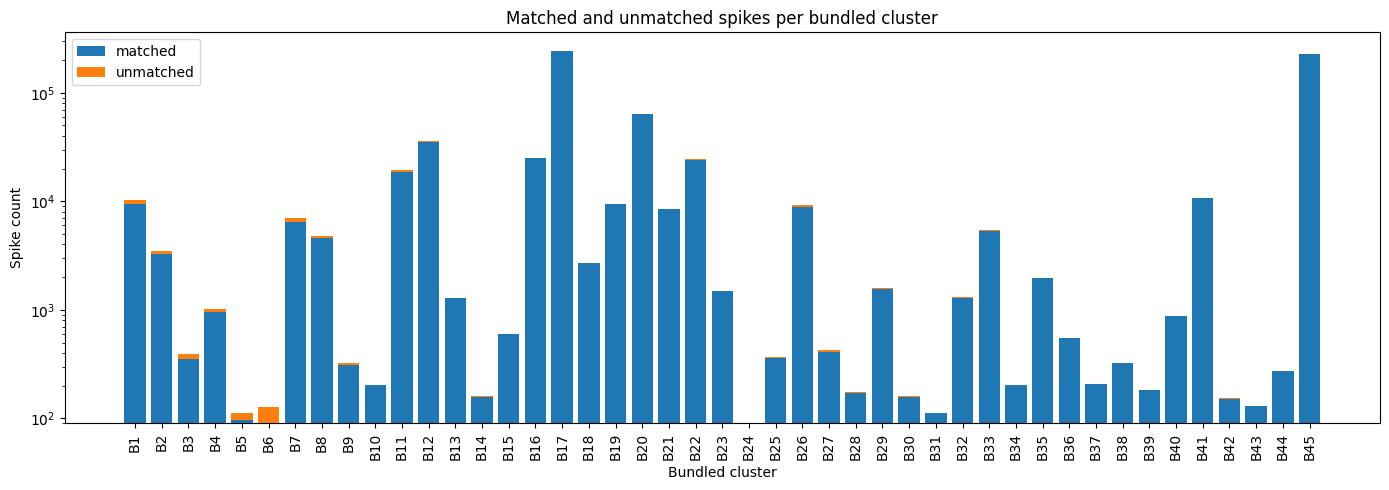

In [20]:
total_bundled = (
    pd.Series(spike_clusters[0])
    .value_counts()
    .rename_axis("bundled_cluster_num")
    .reset_index(name="n_total_spikes")
    .sort_values("bundled_cluster_num")
)

total_bundled["bundled_cluster_id"] = "B" + total_bundled["bundled_cluster_num"].astype(str)

plt.figure(figsize=(14, 4))
plt.bar(total_bundled["bundled_cluster_id"], total_bundled["n_total_spikes"])
plt.xticks(rotation=90)
plt.xlabel("Bundled cluster")
plt.ylabel("Total spike count")
plt.yscale("log")
plt.title("Total spikes per bundled cluster")
plt.tight_layout()
plt.show()
print(np.min(total_bundled["n_total_spikes"]), np.max(total_bundled["n_total_spikes"]))


total_linear = (
    pd.Series(spike_clusters[1])
    .value_counts()
    .rename_axis("linear_cluster_num")
    .reset_index(name="n_total_spikes")
    .sort_values("linear_cluster_num")
)

total_linear["linear_cluster_id"] = "L" + total_linear["linear_cluster_num"].astype(str)

plt.figure(figsize=(14, 4))
plt.bar(total_linear["linear_cluster_id"], total_linear["n_total_spikes"])
plt.xticks(rotation=90)
plt.xlabel("Linear cluster")
plt.ylabel("Total spike count")
plt.yscale("log")
plt.title("Total spikes per linear cluster")
plt.tight_layout()
plt.show()
print(np.min(total_linear["n_total_spikes"]), np.max(total_linear["n_total_spikes"]))

################################

# total spikes per bundled cluster
total_counts = (
    pd.Series(spike_clusters[0])
    .value_counts()
    .rename_axis("bundled_cluster_num")
    .reset_index(name="n_total_spikes")
)

total_counts["bundled_cluster_id"] = (
    "B" + total_counts["bundled_cluster_num"].astype(str)
)

# unmatched bundled spikes per bundled cluster
unmatched_counts = res["unmatched_bundled_counts"].copy()

# if unmatched_counts still uses old numeric column name, convert it
if "bundled_cluster" in unmatched_counts.columns:
    unmatched_counts = unmatched_counts.rename(
        columns={"bundled_cluster": "bundled_cluster_num"}
    )
    unmatched_counts["bundled_cluster_id"] = (
        "B" + unmatched_counts["bundled_cluster_num"].astype(str)
    )

# merge using string ID
plot_df = total_counts.merge(
    unmatched_counts[["bundled_cluster_id", "n_unmatched_bundled_spikes"]],
    on="bundled_cluster_id",
    how="left"
)

plot_df["n_unmatched_bundled_spikes"] = (
    plot_df["n_unmatched_bundled_spikes"].fillna(0).astype(int)
)

plot_df["n_matched_bundled_spikes"] = (
    plot_df["n_total_spikes"] - plot_df["n_unmatched_bundled_spikes"]
)

plot_df = plot_df.sort_values("bundled_cluster_num")

x = np.arange(len(plot_df))

plt.figure(figsize=(14, 5))

plt.bar(
    x,
    plot_df["n_matched_bundled_spikes"],
    label="matched"
)

plt.bar(
    x,
    plot_df["n_unmatched_bundled_spikes"],
    bottom=plot_df["n_matched_bundled_spikes"],
    label="unmatched"
)

plt.xticks(x, plot_df["bundled_cluster_id"], rotation=90)
plt.xlabel("Bundled cluster")
plt.ylabel("Spike count")
plt.title("Matched and unmatched spikes per bundled cluster")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

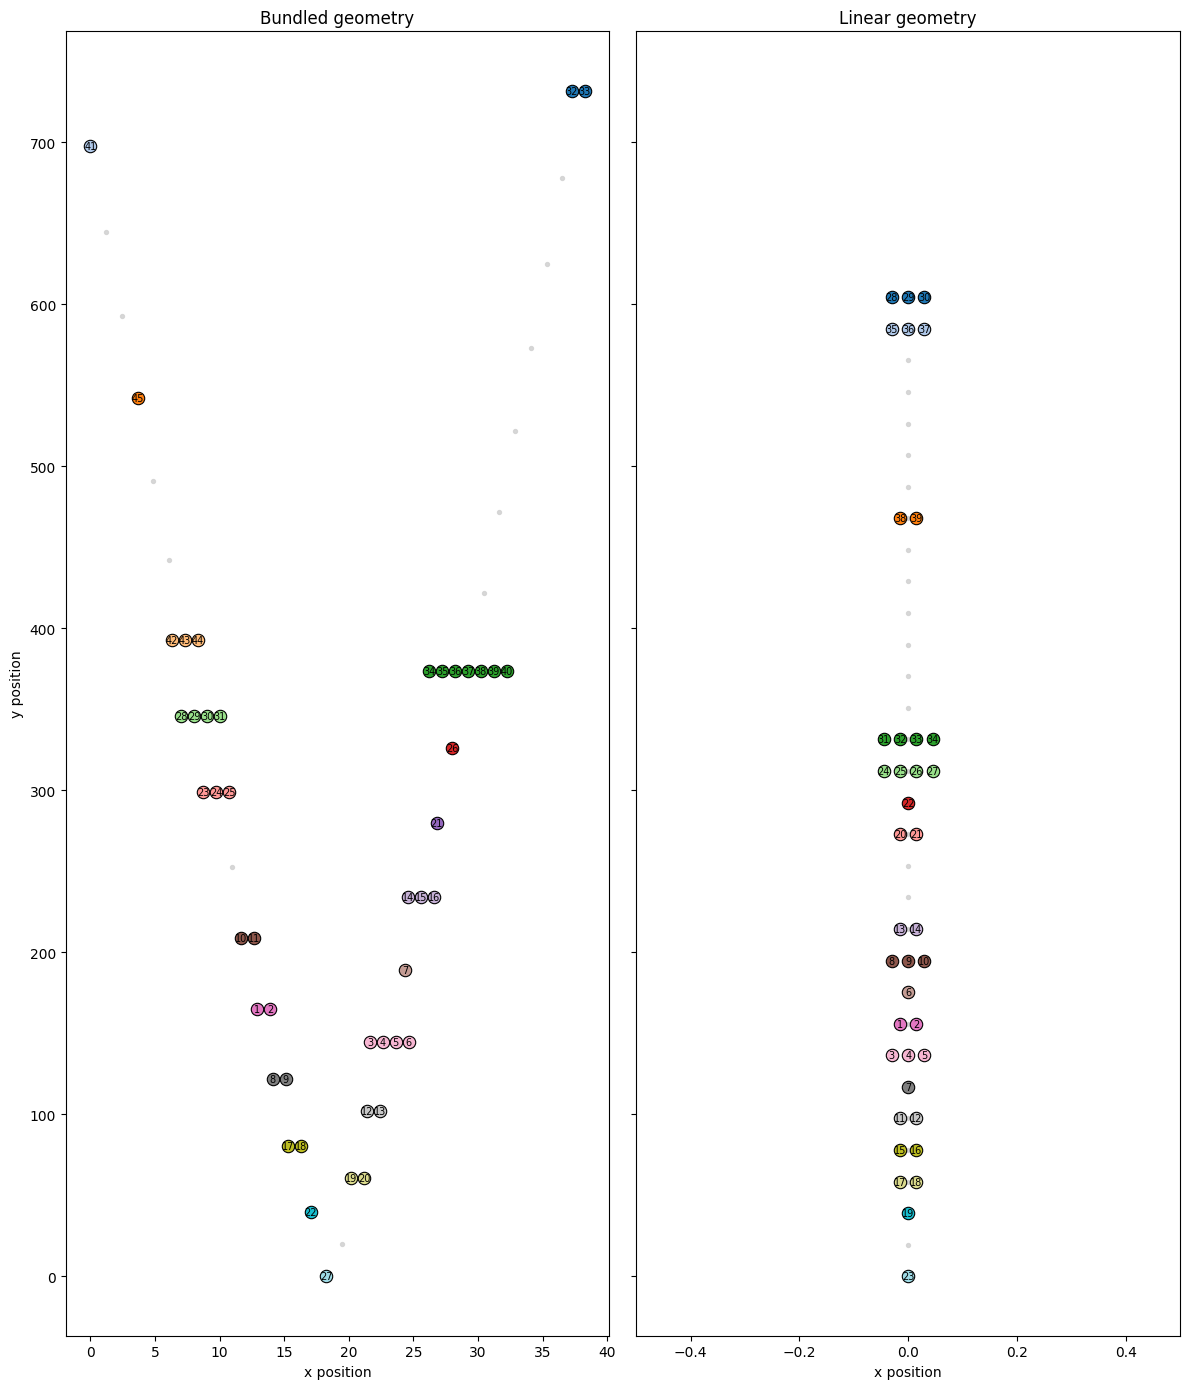

In [21]:
def plot_probe_cluster_locations(
    siteLoc_bundled,
    siteLoc_linear,
    b_cluster_data,
    l_cluster_data,
    x_shift=-3000,
    cluster_id_offset=1,
    figsize=(12, 14),
):
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=True)

    b_peak_indices = b_cluster_data[1, :].astype(int)
    l_peak_indices = l_cluster_data[1, :].astype(int)
    all_peak_ids = np.unique(np.r_[b_peak_indices, l_peak_indices])
    cmap = plt.get_cmap("tab20", len(all_peak_ids))
    color_map = {pid: cmap(i) for i, pid in enumerate(all_peak_ids)}

    panels = [
        (axs[0], np.asarray(siteLoc_bundled), "Bundled geometry", b_peak_indices, 1),
        (axs[1], np.asarray(siteLoc_linear), "Linear geometry", l_peak_indices, 0.03),
    ]

    for ax, geom, title, peak_ids, marker_space in panels:
        x = geom[32:, 0] + x_shift
        y = geom[32:, 1]

        # Plot all probe sites
        ax.scatter(
            x,
            y,
            s=8,
            c="lightgray",
            alpha=0.9,
            label="Probe sites",
            zorder=1,
        )

        # For each peak channel, find which clusters sit there
        unique_peak_ids = np.unique(peak_ids)
        
        for peak_id in unique_peak_ids:
            cluster_inds = np.where(peak_ids == peak_id)[0]
            n = len(cluster_inds)

            offsets = (np.arange(n) - (n-1) /2) * marker_space

            for offset, cluster_ind in zip(offsets, cluster_inds):
                cx = geom[:,0][peak_id] - 3000 + offset
                cy = geom[:,1][peak_id]

                label = cluster_ind + cluster_id_offset

                ax.scatter(
                    cx,
                    cy,
                    s=80,
                    color = color_map[peak_id],
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=3,
                )

                ax.text(
                    cx,
                    cy,
                    str(label),
                    ha="center",
                    va="center",
                    fontsize=7,
                    zorder=4,
                )

        ax.set_title(title)
        ax.set_xlabel("x position")
        if title == "Linear geometry":
            ax.set_xlim(-0.5, 0.5)

    axs[0].set_ylabel("y position")
    

    plt.tight_layout()
    plt.show()

plot_probe_cluster_locations(
    siteLoc_bundled,
    siteLoc_linear,
    b_cluster_data,
    l_cluster_data,
)

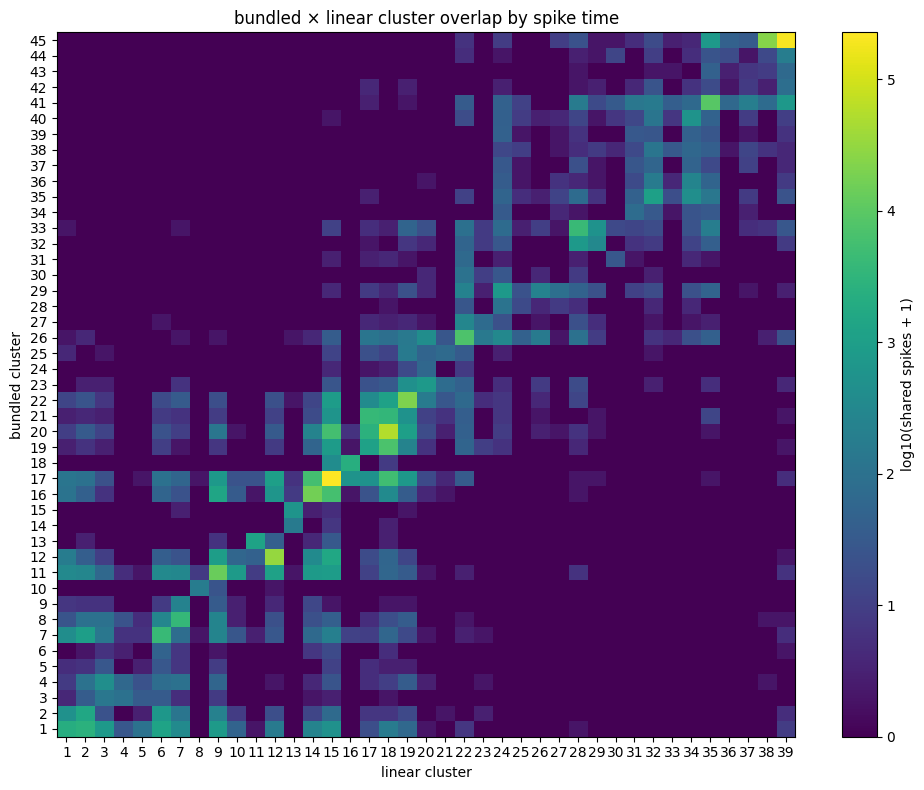

In [22]:
res['overlap']

# plot a heat map of overlapping spikes for each unit pairing 
def plot_overlap_heatmap(overlap, name_A="bundled", name_B="linear", log=True):
    mat = overlap.pivot_table(
        index=f"{name_A}_cluster",
        columns=f"{name_B}_cluster",
        values="n_shared_spikes",
        fill_value=0,
        aggfunc="sum",
    ).sort_index(axis=0).sort_index(axis=1)

    data = mat.to_numpy()

    if log:
        data = np.log10(data + 1)

    plt.figure(figsize=(10, 8))
    im = plt.imshow(data, aspect="auto", origin="lower")

    plt.xticks(np.arange(mat.shape[1]), mat.columns)
    plt.yticks(np.arange(mat.shape[0]), mat.index)

    plt.xlabel(f"{name_B} cluster")
    plt.ylabel(f"{name_A} cluster")

    cbar = plt.colorbar(im)
    cbar.set_label("log10(shared spikes + 1)" if log else "Shared spikes")

    plt.title(f"{name_A} × {name_B} cluster overlap by spike time")
    plt.tight_layout()
    plt.show()

    return mat

overlap_mat = plot_overlap_heatmap(
    res["overlap"],
    name_A="bundled",
    name_B="linear",
    log=True
)

For further visualization on the composition of each linear cluster in relation to bundled clusters. This is a valid analysis as each spike in a linear cluster exists in a bundled cluster as determined previously. 

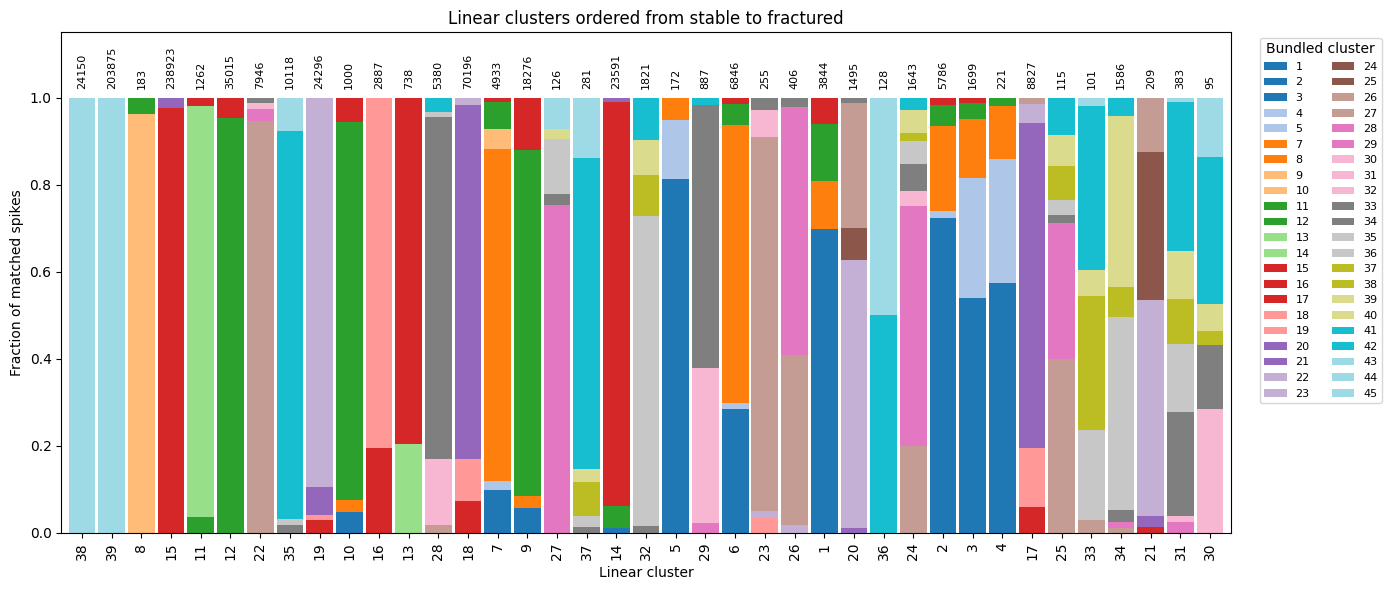

In [23]:
def plot_linear_to_bundled_stacked_sorted(
    overlap,
    min_frac=0.01,
    normalize=True,
    figsize=(14, 6),
):
    df = overlap.copy()

    df = df[df["frac_of_linear"] >= min_frac]

    mat = df.pivot_table(
        index="linear_cluster",
        columns="bundled_cluster",
        values="n_shared_spikes",
        aggfunc="sum",
        fill_value=0,
    )

    frac_mat = mat.div(mat.sum(axis=1), axis=0)

    # Higher max fraction = more solid/stable cluster
    solidity = frac_mat.max(axis=1)

    # Left = most solid, right = most fractured
    order = solidity.sort_values(ascending=False).index

    mat = mat.loc[order]
    totals = mat.sum(axis=1) # before normalization 
    
    if normalize:
        mat = mat.div(mat.sum(axis=1), axis=0)

    ax = mat.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        width=0.9,
        colormap="tab20",
    )

    ax.set_xlabel("Linear cluster")
    ax.set_ylabel("Fraction of matched spikes" if normalize else "Shared spikes")
    ax.set_title("Linear clusters ordered from stable to fractured")
    
    

    y_offset = 0.02 if normalize else totals.max() * 0.01
    ax.set_ylim(0, 1.15)

    for i, total in enumerate(totals):
        y = 1 if normalize else total
        ax.text(
            i,
            y + y_offset,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.legend(
        title="Bundled cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        ncol=2,
    )

    plt.tight_layout()
    plt.show()

    return solidity.loc[order]
    
solid_loc_order = plot_linear_to_bundled_stacked_sorted(res["overlap"])

stop


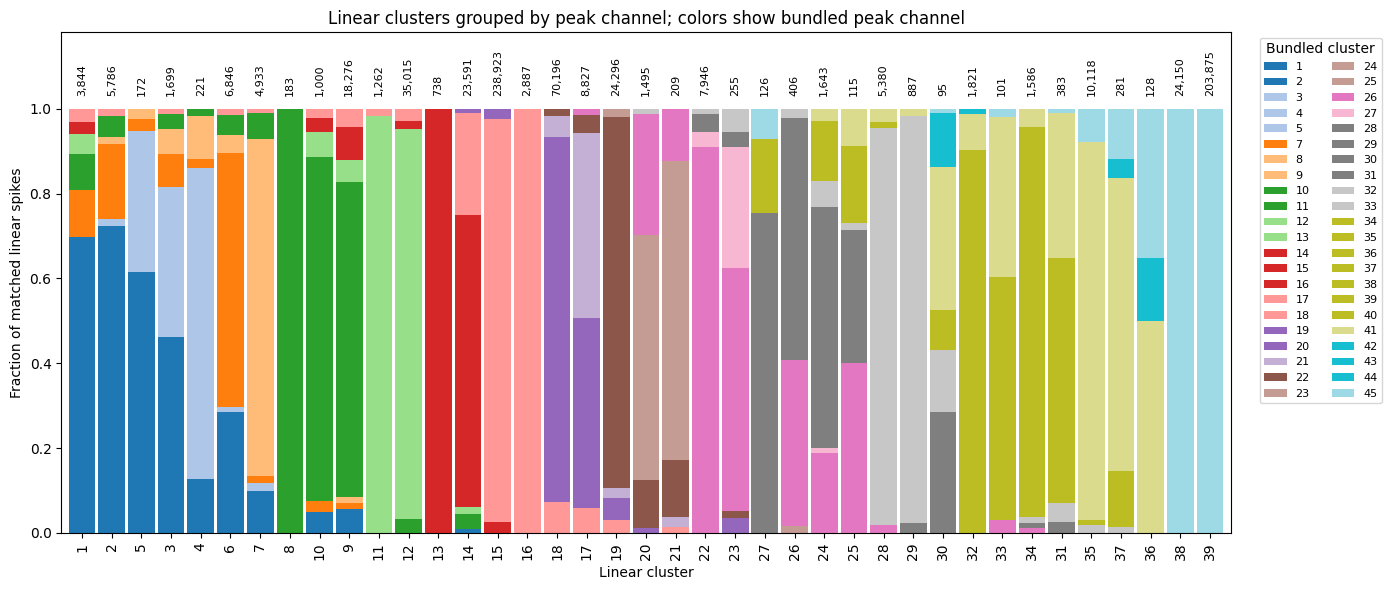

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def peak_maps_from_groups(clusters):
    b_peak, l_peak = {}, {}

    for group in clusters:
        chan = group[0][3]

        for item in group:
            sorter_id = item[0]      # 0 = bundled, 1 = linear
            cluster_id = item[1]     # cluster index

            if sorter_id == 0:
                b_peak[cluster_id] = chan
            else:
                l_peak[cluster_id] = chan

    return b_peak, l_peak

def plot_linear_to_bundled_by_peak_channel(
    overlap,
    clusters,
    min_frac=0.01,
    order_by="peak_then_solidity",   # or "solidity"
    figsize=(14, 6),
):
    b_peak, l_peak = peak_maps_from_groups(clusters)
    print("stop")

    df = overlap.loc[overlap["frac_of_linear"] >= min_frac].copy()

    mat_counts = df.pivot_table(
        index="linear_cluster",
        columns="bundled_cluster",
        values="n_shared_spikes",
        aggfunc="sum",
        fill_value=0,
    )

    totals = mat_counts.sum(axis=1)
    mat_frac = mat_counts.div(totals, axis=0)

    solidity = mat_frac.max(axis=1)

    if order_by == "peak_then_solidity":
        order = sorted(
            mat_frac.index,
            key=lambda c: (
                l_peak.get(c, np.inf),
                -solidity.loc[c],
            ),
        )
    elif order_by == "solidity":
        order = solidity.sort_values(ascending=False).index
    else:
        order = mat_frac.index

    mat_frac = mat_frac.loc[order]
    totals = totals.loc[order]
    solidity = solidity.loc[order]

    # One color per bundled peak channel
    peak_channels = sorted({b_peak.get(c) for c in mat_frac.columns})
    cmap = plt.get_cmap("tab20", len(peak_channels))
    peak_to_color = {ch: cmap(i) for i, ch in enumerate(peak_channels)}
    colors = [peak_to_color[b_peak.get(c)] for c in mat_frac.columns]

    ax = mat_frac.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        width=0.9,
        color=colors,
    )

    ax.set_xlabel("Linear cluster")
    ax.set_ylabel("Fraction of matched linear spikes")
    ax.set_title("Linear clusters grouped by peak channel; colors show bundled peak channel")
    ax.set_ylim(0, 1.18)

    for i, total in enumerate(totals):
        ax.text(
            i,
            1.03,
            f"{int(total):,}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.legend(
        title="Bundled cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        ncol=2,
    )

    plt.tight_layout()
    plt.show()

    return solidity

clusters = cluster_units_by_channel_radius(
    unit_arrays=[b_cluster_data.T, l_cluster_data.T],
    chan_map=siteMap_bundled,
    radius=0,
)


solid_loc_order = plot_linear_to_bundled_by_peak_channel(
    res["overlap"],
    clusters,
    min_frac=0.01,
    order_by="peak_then_solidity")

***
We'll start by analyzing cluster B17 and L15 

In [25]:
B_unit_id = 17
L_unit_id = 15

B_unit_data = extract_unit_data_JRCLUST(res_mat_path=bundled_res_mat_path, spikesFilt_mat_path=bundled_spikesFilt_path, siteMap = siteMap_bundled, cluster_id=B_unit_id)
L_unit_data = extract_unit_data_JRCLUST(res_mat_path=linear_res_mat_path, spikesFilt_mat_path=linear_spikesFilt_path, siteMap = siteMap_linear, cluster_id=L_unit_id)

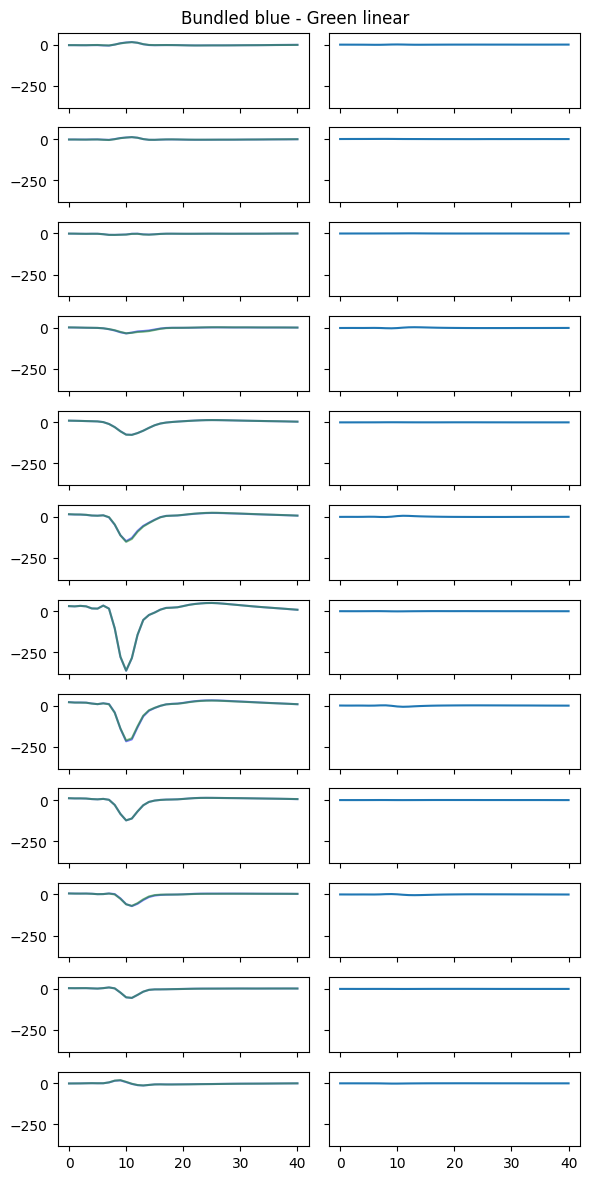

In [27]:
# plot waveforms (shape = 242544, 12, 41)

lin_indices_order = [11, 9, 7, 5, 3, 1, 0, 2, 4, 6, 8, 10]
bund_indices_order = [11, 10, 8, 6, 4, 2, 0, 1, 3, 5, 7, 9]
fig, axes = plt.subplots(12, 2, figsize=(6, 12), sharex=True, sharey=True)

mean_b =  np.mean(B_unit_data["spike_waveforms"], axis=0)
mean_l = np.mean(L_unit_data["spike_waveforms"], axis=0)

for i in range(12):   
    axes[i, 0].plot(np.arange(41), mean_b[bund_indices_order[i]], alpha=0.5, color="blue")
    axes[i, 0].plot(np.arange(41), mean_l[lin_indices_order[i]], alpha=0.5, color='green')
    axes[i, 1].plot(np.arange(41), mean_b[bund_indices_order[i]]-mean_l[lin_indices_order[i]])

plt.suptitle("Bundled blue - Green linear")
plt.tight_layout()
plt.show()

Bundled cluster 17 has 242544 spikes total, 227395 are shared with the cluster L (93.75412296325615%)
Linear cluster 15 has 245200 spikes total; 92.73858075040783% shared with cluster B
(15149,) (17805,)


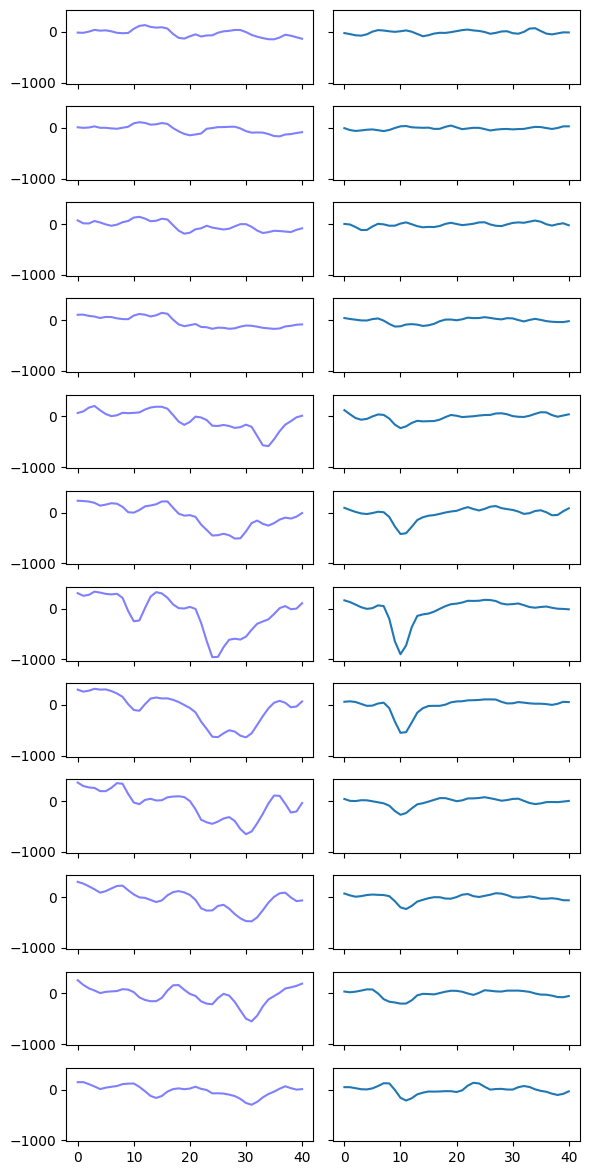

Shared corr: 0.5594510082001088
B-only corr: 0.49818938333359003
L-only corr: 0.4975612852792214
Shared amp: 510.0
B-only amp: 520.0
L-only amp: 507.0


'# which of these have matches at all / where are they mapped to \n\n# the matches array has shape rec sample len x 2 with index :,0 being bundled matching index and :,1 being the corresponding spike index \nall_B_matched_spike_samples = matches[:,0]\noutB = identical_spikes(all_B_matched_spike_samples, B_unit_data["spike_times"][idx_B]) # matched spikes \nB_samples_matched_in_curr = outB[:,1]\nall_L_matched_spike_samples = matches[:,1]\noutL = identical_spikes(all_L_matched_spike_samples, L_unit_data["spike_times"][idx_L])\nL_samples_matched_in_curr = outL[:,1]\n\nprint(f"Of the {len(idx_B)} shared spikes between cluster B and L, B_samples_matched_in_curr.shape, L_samples_matched_in_curr.shape")\n\n# determine how spread these are over the recording \n# determine the waveform correlation between them'

In [48]:
out = identical_spikes(B_unit_data["spike_times"], L_unit_data["spike_times"])
idx_B = out[:, 0] # indicies of B_unit spike times that are identical to L_unit spike times
idx_L = out[:, 1] # indices of L_unit spike times that are identical to B_unit spike times

# print how many spikes are matched between the two clusters 
print(f"Bundled cluster {B_unit_id} has {B_unit_data["spike_times"].shape[0]} spikes total, {len(idx_B)} are shared with the cluster L ({len(idx_B)/B_unit_data["spike_times"].shape[0] * 100}%)")
print(f"Linear cluster {L_unit_id} has {L_unit_data["spike_times"].shape[0]} spikes total; {len(idx_L)/L_unit_data["spike_times"].shape[0] * 100}% shared with cluster B")

# because these matching spikes will have very similar waveforms, we will focus our analysis on the spikes that are not common to both units 
        # there are extra spikes from the linear cluster (which have a matched spike in another bundled cluster)
        # and there are extra spikes from the bundled cluster that may or may not have a match in another linear cluster 
        
# get the sample value of B spikes that are in unit cluster but not in L unit 
B_in_clus_matching_mask = np.zeros(len(B_unit_data["spike_times"]), dtype=bool)
B_in_clus_matching_mask[idx_B] = True

unmatched_in_Bclus_samples = B_unit_data["spike_times"][~B_in_clus_matching_mask] # total b unit spikes - those that match with L cluster 

# get the sample value of L spikes that are in unit cluster but not in B unit 
L_in_clus_matching_mask = np.zeros(len(L_unit_data["spike_times"]), dtype=bool)
L_in_clus_matching_mask[idx_L] = True

unmatched_in_Lclus_samples = L_unit_data["spike_times"][~L_in_clus_matching_mask] # total l unit spikes - those that match with B cluster 

print(unmatched_in_Bclus_samples.shape, unmatched_in_Lclus_samples.shape)

#########################################
# look at the waveforms of the spikes that aren't matching 
unit_b_unmatched_waveforms = B_unit_data["spike_waveforms"][~B_in_clus_matching_mask]
unit_l_unmatched_waveforms = L_unit_data["spike_waveforms"][~L_in_clus_matching_mask]

# plot the correlation of each of these spike waveforms to those of the mean matching spike waveform 
unit_b_matched_mean_waveform =  np.mean(B_unit_data["spike_waveforms"][B_in_clus_matching_mask], axis=0) # (shape 12x41)
unit_l_matched_mean_waveform = np.mean(L_unit_data["spike_waveforms"][L_in_clus_matching_mask], axis=0)

# euclidean distance (sum over multiple channels)
# correlation (though measures change not amplitude for example) 
# cosine similarity 
# mahalanobis distance 

import numpy as np

def waveform_template_metrics(waveforms, template=None):
    """
    waveforms: array, shape (n_spikes, n_channels, n_samples)
    template: optional array, shape (n_channels, n_samples)

    returns:
        corr: correlation of each waveform to template
        cosine: cosine similarity of each waveform to template
        l2: Euclidean distance to template
        amplitude: peak-to-trough amplitude per waveform
    """

    waveforms = np.asarray(waveforms)

    if template is None:
        template = waveforms.mean(axis=0)

    # Flatten 12 x 41 -> 492
    W = waveforms.reshape(waveforms.shape[0], -1)
    T = template.reshape(-1)

    # Pearson correlation to template
    W_centered = W - W.mean(axis=1, keepdims=True)
    T_centered = T - T.mean()

    corr = (
        W_centered @ T_centered
        / (
            np.linalg.norm(W_centered, axis=1)
            * np.linalg.norm(T_centered)
        )
    )

    # Cosine similarity to template
    cosine = (
        W @ T
        / (
            np.linalg.norm(W, axis=1)
            * np.linalg.norm(T)
        )
    )

    # Euclidean distance to template
    l2 = np.linalg.norm(W - T, axis=1)

    # Peak-to-trough amplitude across all channels and samples
    amplitude = waveforms.max(axis=(1, 2)) - waveforms.min(axis=(1, 2))
    
    np.where(corr == np.min(corr))

    return {
        "corr": corr,
        "cosine": cosine,
        "l2": l2,
        "amplitude": amplitude,
        "template": template,
        "least_corr": waveforms[np.where(corr == np.min(corr))],
        "most_corr": waveforms[np.where(corr == np.max(corr))]
    }



metrics_shared = waveform_template_metrics(B_unit_data["spike_waveforms"][B_in_clus_matching_mask])

metrics_B_only = waveform_template_metrics(unit_b_unmatched_waveforms, template=np.mean(B_unit_data["spike_waveforms"], axis=0))
metrics_L_only = waveform_template_metrics(unit_l_unmatched_waveforms, template=np.mean(L_unit_data["spike_waveforms"], axis=0))


lin_indices_order = [11, 9, 7, 5, 3, 1, 0, 2, 4, 6, 8, 10]
bund_indices_order = [11, 10, 8, 6, 4, 2, 0, 1, 3, 5, 7, 9]

fig, axes = plt.subplots(12, 2, figsize=(6, 12), sharex=True, sharey=True)

for i in range(12):   
    axes[i, 0].plot(np.arange(41), metrics_B_only["least_corr"].squeeze()[bund_indices_order[i]], alpha=0.5, color="blue")
    #axes[i, 0].plot(np.arange(41), mean_l[lin_indices_order[i]], alpha=0.5, color='green')
    axes[i, 1].plot(np.arange(41), metrics_B_only["most_corr"].squeeze()[bund_indices_order[i]])

plt.suptitle("")
plt.tight_layout()
plt.show()


print("Shared corr:", np.median(metrics_shared["corr"]))
print("B-only corr:", np.median(metrics_B_only["corr"]))
print("L-only corr:", np.median(metrics_L_only["corr"]))

print("Shared amp:", np.median(metrics_shared["amplitude"]))
print("B-only amp:", np.median(metrics_B_only["amplitude"]))
print("L-only amp:", np.median(metrics_L_only["amplitude"]))

"""# which of these have matches at all / where are they mapped to 

# the matches array has shape rec sample len x 2 with index :,0 being bundled matching index and :,1 being the corresponding spike index 
all_B_matched_spike_samples = matches[:,0]
outB = identical_spikes(all_B_matched_spike_samples, B_unit_data["spike_times"][idx_B]) # matched spikes 
B_samples_matched_in_curr = outB[:,1]
all_L_matched_spike_samples = matches[:,1]
outL = identical_spikes(all_L_matched_spike_samples, L_unit_data["spike_times"][idx_L])
L_samples_matched_in_curr = outL[:,1]

print(f"Of the {len(idx_B)} shared spikes between cluster B and L, B_samples_matched_in_curr.shape, L_samples_matched_in_curr.shape")

# determine how spread these are over the recording 
# determine the waveform correlation between them"""


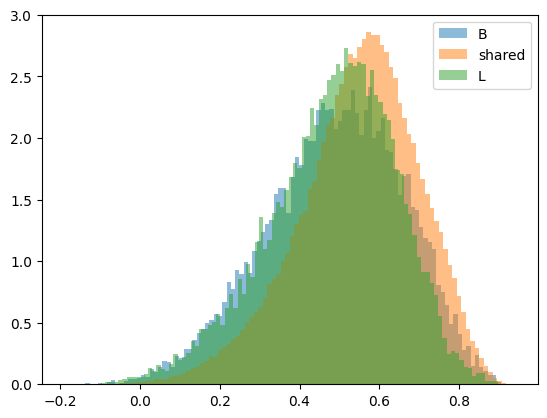

In [42]:
plt.hist(metrics_B_only["corr"], density=True, alpha=0.5, bins=100, label="B")
plt.hist(metrics_shared["corr"], density=True, alpha=0.5, bins=100, label="shared")
plt.hist(metrics_L_only["corr"], density=True, alpha=0.5, bins=100, label="L")
plt.legend()
plt.show()

In [ ]:
# TODO: check up on duplicate spikes in both linear and bundled spikes ! 

***

In [ ]:
unmatched_clusters = bundled_clusters[bundled_mask]
unique, counts = np.unique(
    unmatched_clusters,
    return_counts=True
)

plt.bar(unique, counts)

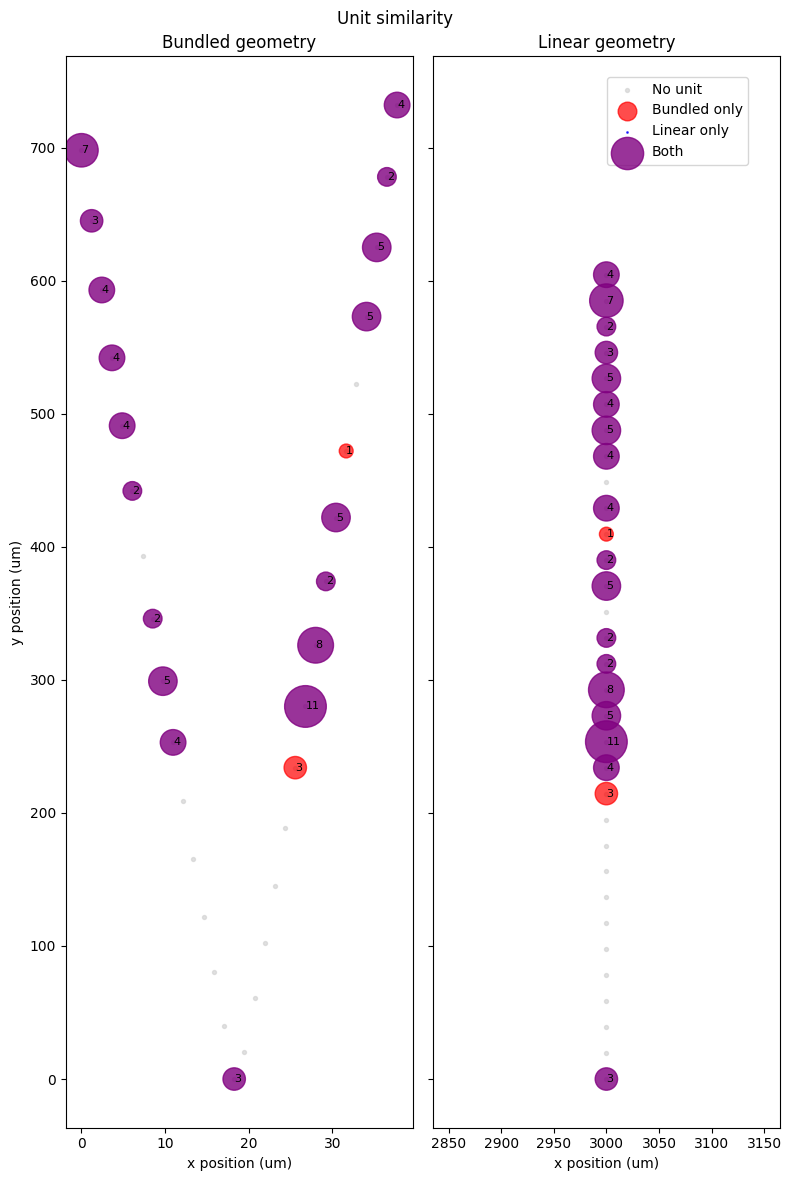

In [4]:
# let's see which units have the same peak channel 

def plot_unit_density_on_geoms(
    bundled_units,
    linear_units,
    chan_map,
    bundled_geom,
    linear_geom,
    size_scale=80,
    base_size=20,
):
    """
    Plot unit density on two probe geometries.

    Red    = bundled units only
    Blue   = linear units only
    Purple = units from both recordings on same channel

    Parameters
    ----------
    bundled_units, linear_units : np.ndarray
        Arrays of shape (n_units, 3):
        [unit_id, peak_chan_id, peak_chan_index]

    chan_map : array-like
        Channel IDs in geometry order.

    bundled_geom, linear_geom : np.ndarray
        Geometry arrays of shape (n_channels, 2), usually x/y positions.

    size_scale : float
        Multiplier for dot size based on number of units.

    base_size : float
        Minimum dot size.
    """

    chan_map = np.asarray(chan_map)
    bundled_units = np.asarray(bundled_units)
    linear_units = np.asarray(linear_units)

    chan_id_to_index = {int(ch): i for i, ch in enumerate(chan_map)}

    bundled_counts = np.zeros(len(chan_map), dtype=int)
    linear_counts = np.zeros(len(chan_map), dtype=int)

    for peak_chan_id in bundled_units[:, 1].astype(int):
        bundled_counts[chan_id_to_index[peak_chan_id]] += 1

    for peak_chan_id in linear_units[:, 1].astype(int):
        linear_counts[chan_id_to_index[peak_chan_id]] += 1

    both = (bundled_counts > 0) & (linear_counts > 0)
    bundled_only = (bundled_counts > 0) & ~both
    linear_only = (linear_counts > 0) & ~both

    total_counts = bundled_counts + linear_counts

    fig, axs = plt.subplots(1, 2, figsize=(8, 12), sharey=True)

    panels = [
        (axs[0], bundled_geom, "Bundled geometry"),
        (axs[1], linear_geom, "Linear geometry"),
    ]

    for ax, geom, title in panels:
        geom = np.asarray(geom)

        ax.scatter(
            geom[:, 0],
            geom[:, 1],
            s=8,
            c="lightgray",
            alpha=0.7,
            label="No unit",
        )

        ax.scatter(
            geom[bundled_only, 0],
            geom[bundled_only, 1],
            s=base_size + size_scale * total_counts[bundled_only],
            c="red",
            alpha=0.7,
            label="Bundled only",
        )

        ax.scatter(
            geom[linear_only, 0],
            geom[linear_only, 1],
            s=base_size + size_scale * total_counts[linear_only],
            c="blue",
            alpha=0.7,
            label="Linear only",
        )

        ax.scatter(
            geom[both, 0],
            geom[both, 1],
            s=base_size + size_scale * total_counts[both],
            c="purple",
            alpha=0.8,
            label="Both",
        )
        
        # label total unit count on non-empty channels
        idx = np.flatnonzero(total_counts > 0)
        for i in idx:
            ax.text(
                geom[i, 0],
                geom[i, 1],
                str(total_counts[i]),
                fontsize=8,
                ha="left",
                va="center",
            )

        ax.set_title(title)
        ax.set_xlabel("x position (um)")

    axs[0].set_ylabel("y position (um)")

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.95, .93))

    fig.suptitle("Unit similarity")
    plt.tight_layout()
    plt.show()

    return {
        "bundled_counts": bundled_counts,
        "linear_counts": linear_counts,
        "total_counts": total_counts,
    }
    
    b_units, b_unit_peak_chan, b_unit_peak_chan_index
counts = plot_unit_density_on_geoms(b_cluster_data.T, l_cluster_data.T, siteMap_bundled[32:], siteLoc_bundled[:32], siteLoc_linear[32:])

We see from the above plot that many units from both geom types have the same peak channel. 

We will look closer in whether the two geometries are detecting the same units. 

(4, 4)
[[ 0  1 55 32]
 [ 0  2 55 32]
 [ 1  1 55 32]
 [ 1  2 55 32]]
Bundled unit 1: 10365 spikes
Bundled unit 2: 3512 spikes
Linear unit 1: 3918 spikes
Linear unit 2: 5984 spikes


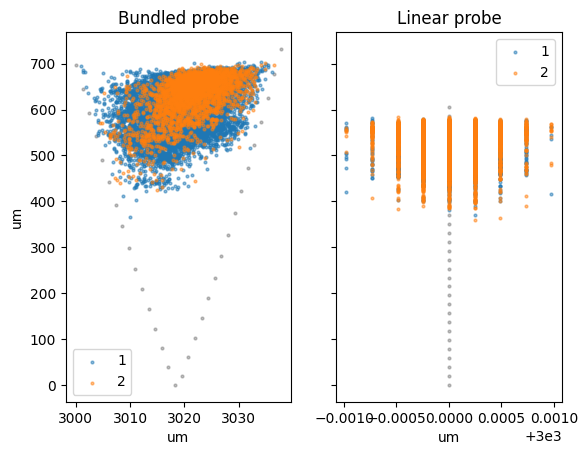

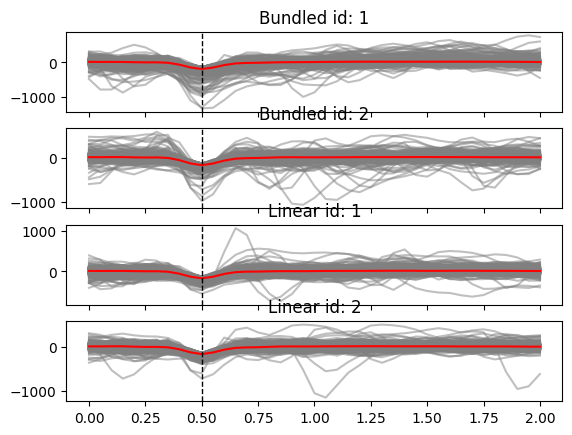

------------------------------------------------------------------------------------------
(7, 4)
[[ 0  3 56 33]
 [ 0  4 56 33]
 [ 0  5 56 33]
 [ 0  6 56 33]
 [ 1  3 56 33]
 [ 1  4 56 33]
 [ 1  5 56 33]]
Bundled unit 3: 393 spikes
Bundled unit 4: 1023 spikes
Bundled unit 5: 111 spikes
Bundled unit 6: 127 spikes
Linear unit 3: 1747 spikes
Linear unit 4: 223 spikes
Linear unit 5: 174 spikes


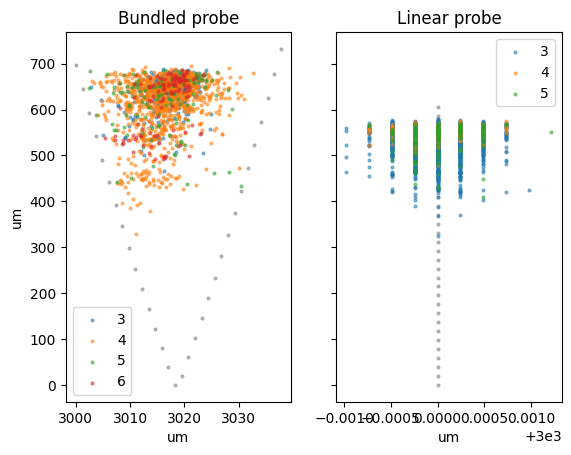

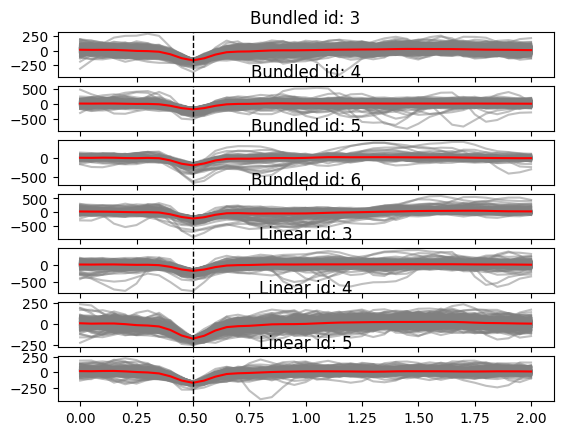

------------------------------------------------------------------------------------------
(2, 4)
[[ 0  7 54 34]
 [ 1  6 54 34]]
Bundled unit 7: 7048 spikes
Linear unit 6: 7107 spikes


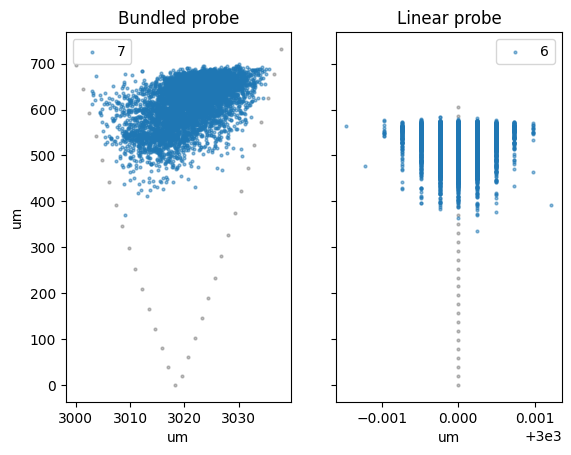

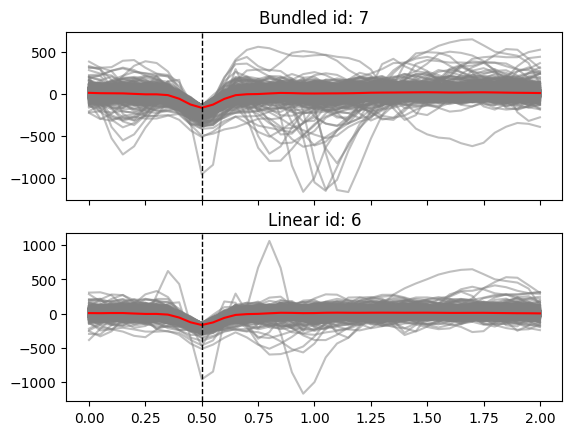

------------------------------------------------------------------------------------------
(3, 4)
[[ 0  8 57 35]
 [ 0  9 57 35]
 [ 1  7 57 35]]
Bundled unit 8: 4812 spikes
Bundled unit 9: 322 spikes
Linear unit 7: 5050 spikes


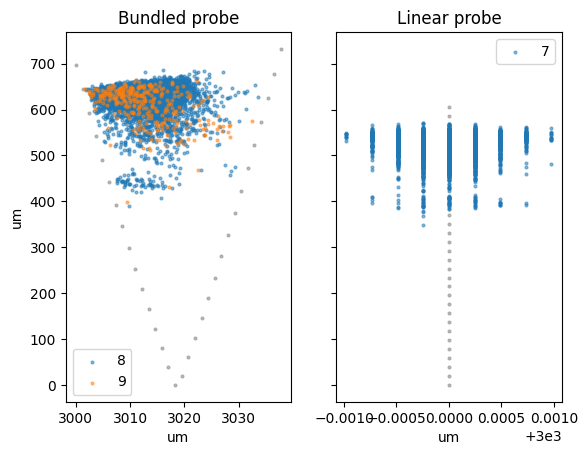

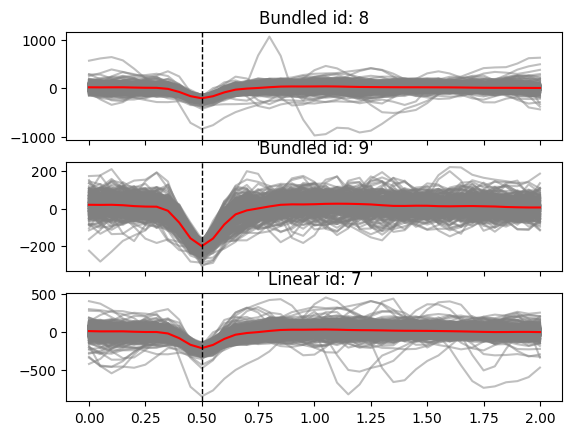

------------------------------------------------------------------------------------------
(5, 4)
[[ 0 10 53 36]
 [ 0 11 53 36]
 [ 1  8 53 36]
 [ 1  9 53 36]
 [ 1 10 53 36]]
Bundled unit 10: 204 spikes
Bundled unit 11: 19372 spikes
Linear unit 8: 185 spikes
Linear unit 9: 18568 spikes
Linear unit 10: 1013 spikes


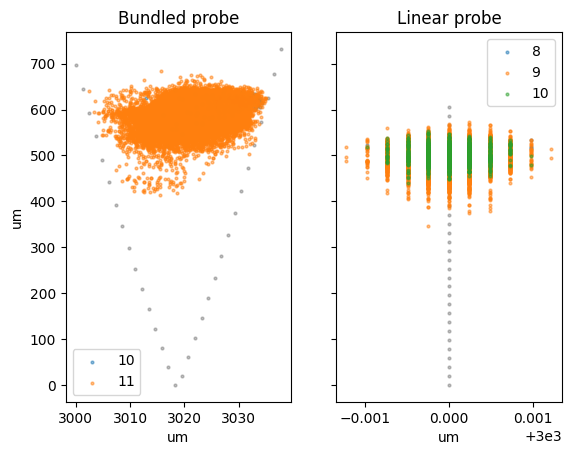

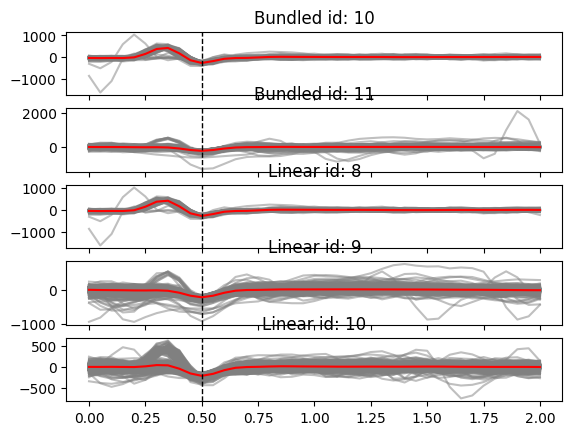

------------------------------------------------------------------------------------------
(4, 4)
[[ 0 12 58 37]
 [ 0 13 58 37]
 [ 1 11 58 37]
 [ 1 12 58 37]]
Bundled unit 12: 35624 spikes
Bundled unit 13: 1278 spikes
Linear unit 11: 1274 spikes
Linear unit 12: 35345 spikes


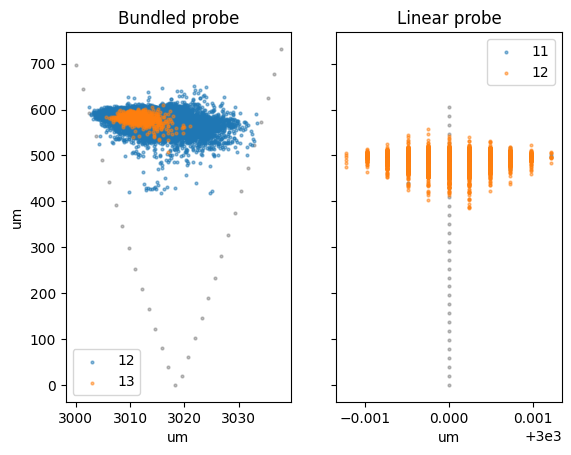

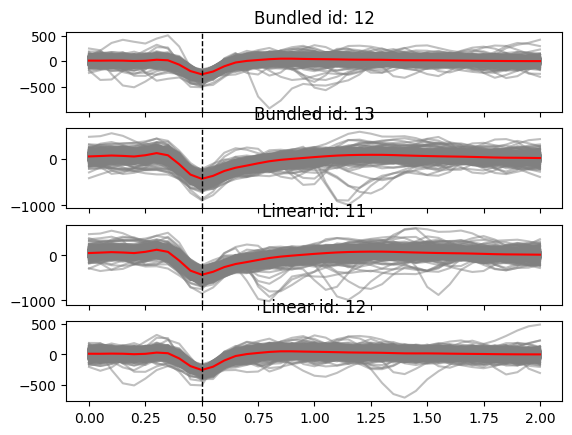

------------------------------------------------------------------------------------------
(5, 4)
[[ 0 14 52 38]
 [ 0 15 52 38]
 [ 0 16 52 38]
 [ 1 13 52 38]
 [ 1 14 52 38]]
Bundled unit 14: 160 spikes
Bundled unit 15: 598 spikes
Bundled unit 16: 25042 spikes
Linear unit 13: 753 spikes
Linear unit 14: 23798 spikes


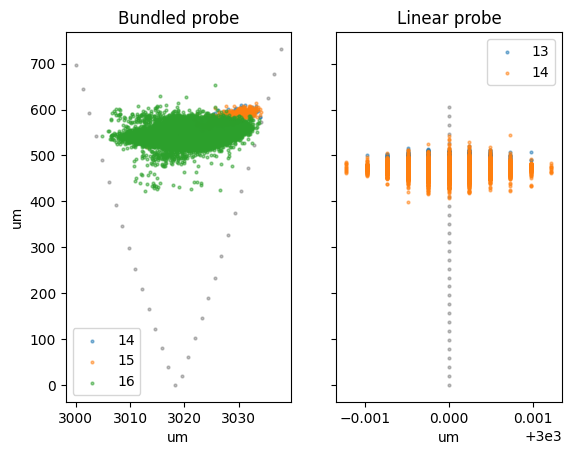

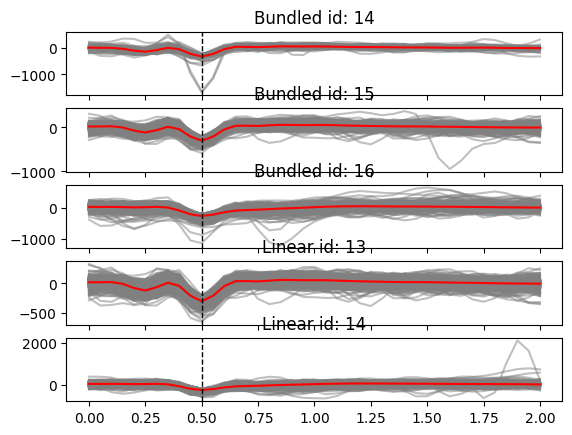

------------------------------------------------------------------------------------------
(4, 4)
[[ 0 17 59 39]
 [ 0 18 59 39]
 [ 1 15 59 39]
 [ 1 16 59 39]]
Bundled unit 17: 242544 spikes
Bundled unit 18: 2726 spikes
Linear unit 15: 245200 spikes
Linear unit 16: 2904 spikes


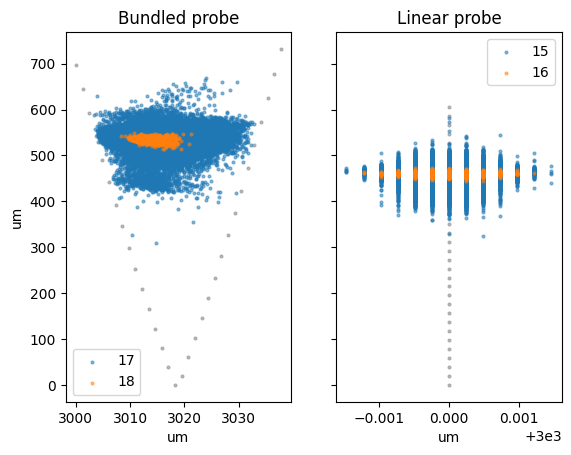

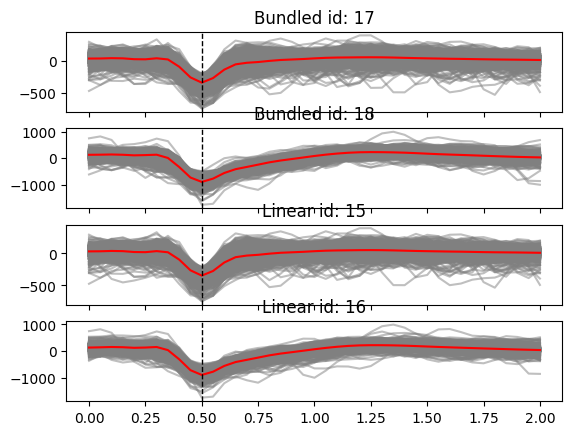

------------------------------------------------------------------------------------------
(4, 4)
[[ 0 19 60 41]
 [ 0 20 60 41]
 [ 1 17 60 41]
 [ 1 18 60 41]]
Bundled unit 19: 9391 spikes
Bundled unit 20: 63665 spikes
Linear unit 17: 8985 spikes
Linear unit 18: 71087 spikes


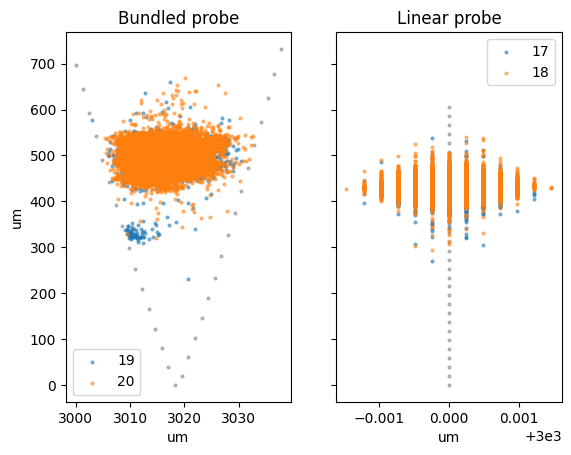

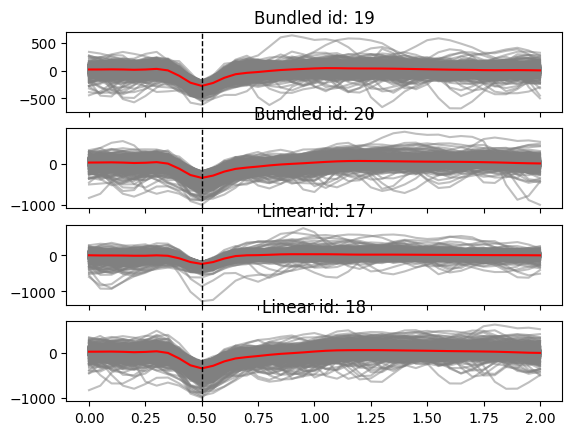

------------------------------------------------------------------------------------------
(2, 4)
[[ 0 22 61 43]
 [ 1 19 61 43]]
Bundled unit 22: 24329 spikes
Linear unit 19: 24945 spikes


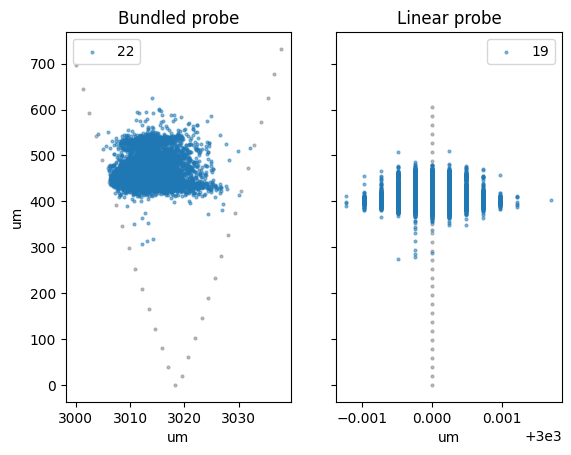

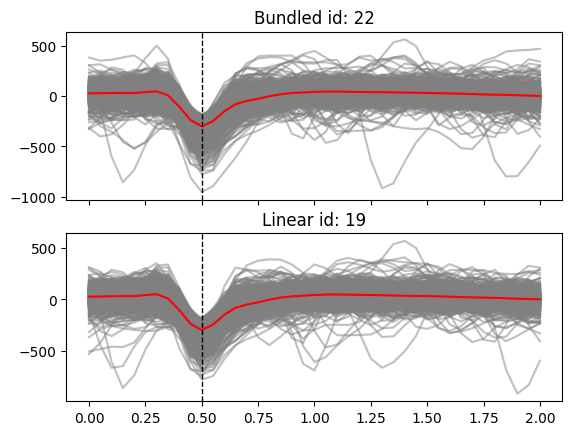

------------------------------------------------------------------------------------------
(5, 4)
[[ 0 23 49 44]
 [ 0 24 49 44]
 [ 0 25 49 44]
 [ 1 20 49 44]
 [ 1 21 49 44]]
Bundled unit 23: 1504 spikes
Bundled unit 24: 90 spikes
Bundled unit 25: 364 spikes
Linear unit 20: 1544 spikes
Linear unit 21: 213 spikes


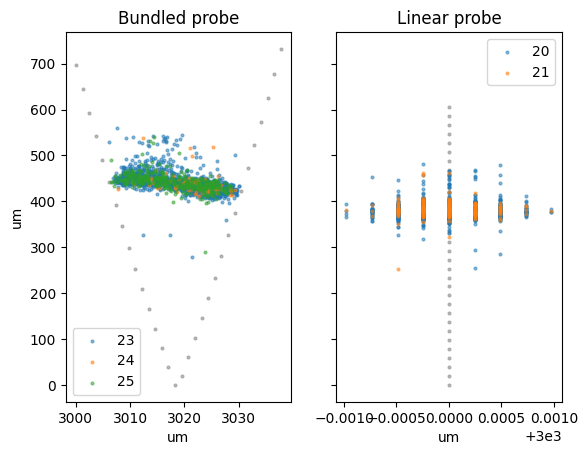

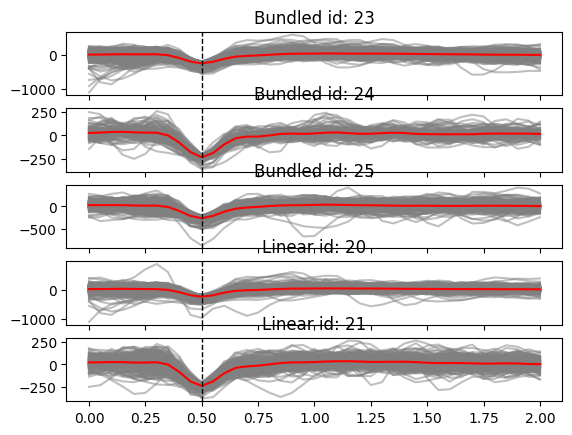

------------------------------------------------------------------------------------------
(2, 4)
[[ 0 26 48 46]
 [ 1 22 48 46]]
Bundled unit 26: 9159 spikes
Linear unit 22: 8491 spikes


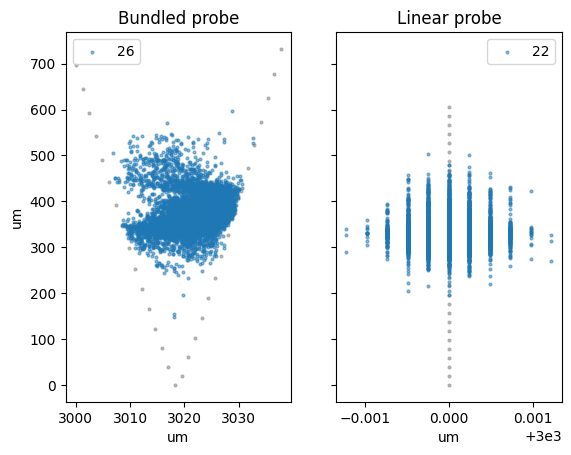

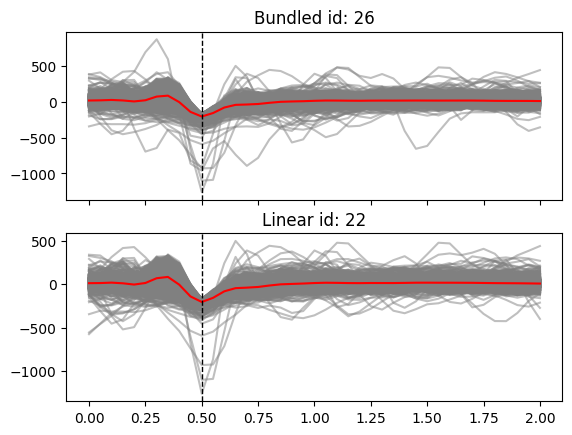

------------------------------------------------------------------------------------------
(2, 4)
[[ 0 27 63 47]
 [ 1 23 63 47]]
Bundled unit 27: 430 spikes
Linear unit 23: 261 spikes


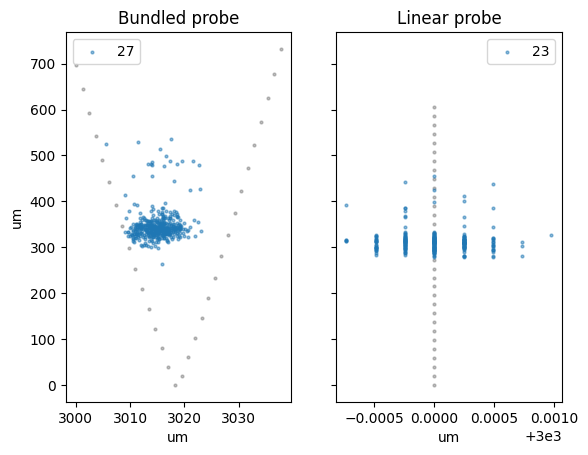

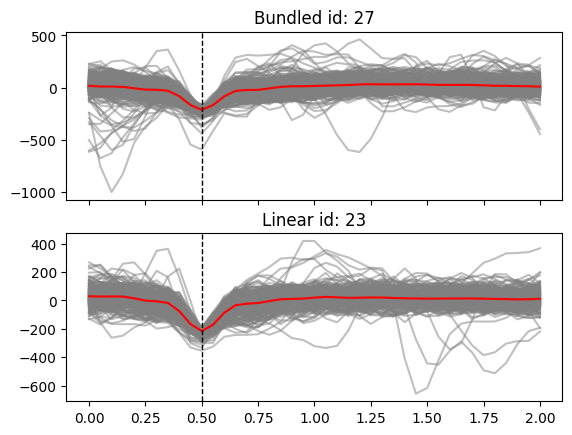

------------------------------------------------------------------------------------------
(8, 4)
[[ 0 28 47 48]
 [ 0 29 47 48]
 [ 0 30 47 48]
 [ 0 31 47 48]
 [ 1 24 47 48]
 [ 1 25 47 48]
 [ 1 26 47 48]
 [ 1 27 47 48]]
Bundled unit 28: 176 spikes
Bundled unit 29: 1590 spikes
Bundled unit 30: 162 spikes
Bundled unit 31: 112 spikes
Linear unit 24: 1700 spikes
Linear unit 25: 118 spikes
Linear unit 26: 423 spikes
Linear unit 27: 131 spikes


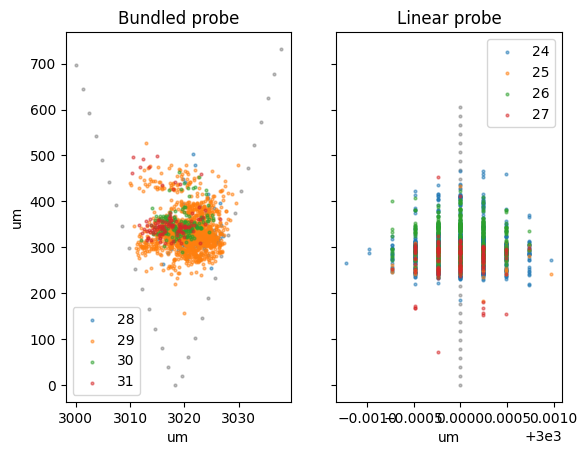

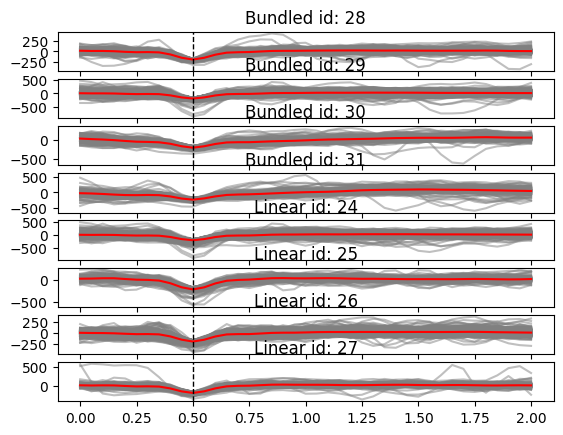

------------------------------------------------------------------------------------------
(5, 4)
[[ 0 32 32 49]
 [ 0 33 32 49]
 [ 1 28 32 49]
 [ 1 29 32 49]
 [ 1 30 32 49]]
Bundled unit 32: 1312 spikes
Bundled unit 33: 5395 spikes
Linear unit 28: 5572 spikes
Linear unit 29: 921 spikes
Linear unit 30: 95 spikes


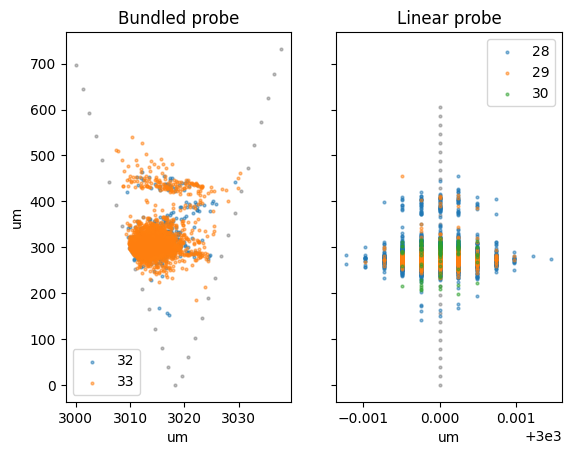

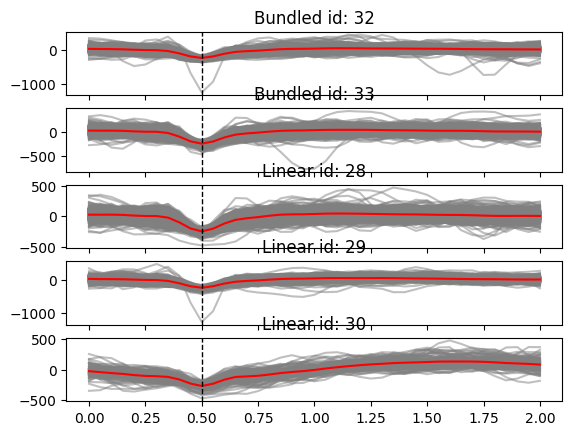

------------------------------------------------------------------------------------------
(11, 4)
[[ 0 34 46 50]
 [ 0 35 46 50]
 [ 0 36 46 50]
 [ 0 37 46 50]
 [ 0 38 46 50]
 [ 0 39 46 50]
 [ 0 40 46 50]
 [ 1 31 46 50]
 [ 1 32 46 50]
 [ 1 33 46 50]
 [ 1 34 46 50]]
Bundled unit 34: 205 spikes
Bundled unit 35: 1957 spikes
Bundled unit 36: 553 spikes
Bundled unit 37: 207 spikes
Bundled unit 38: 325 spikes
Bundled unit 39: 184 spikes
Bundled unit 40: 882 spikes
Linear unit 31: 387 spikes
Linear unit 32: 1902 spikes
Linear unit 33: 103 spikes
Linear unit 34: 1616 spikes


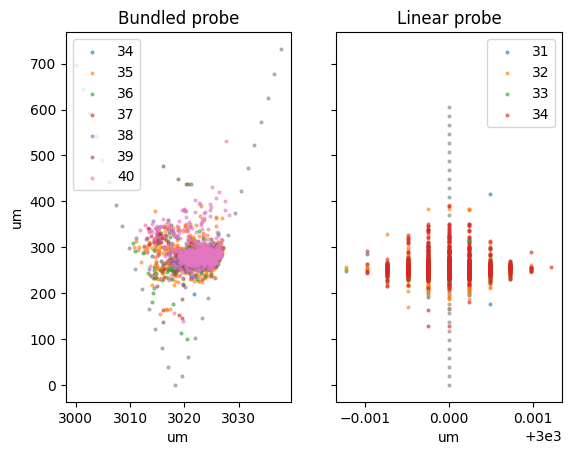

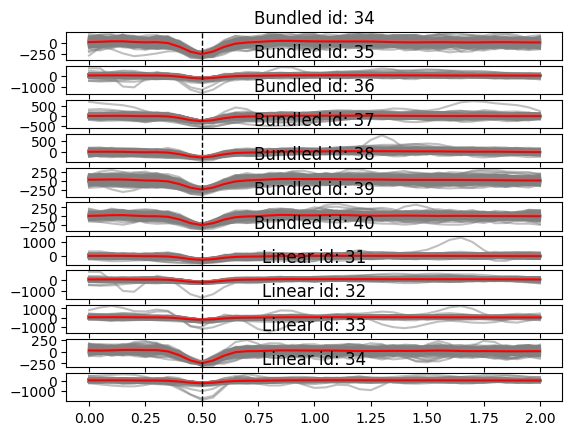

------------------------------------------------------------------------------------------
(4, 4)
[[ 0 41 33 51]
 [ 1 35 33 51]
 [ 1 36 33 51]
 [ 1 37 33 51]]
Bundled unit 41: 10779 spikes
Linear unit 35: 10568 spikes
Linear unit 36: 130 spikes
Linear unit 37: 286 spikes


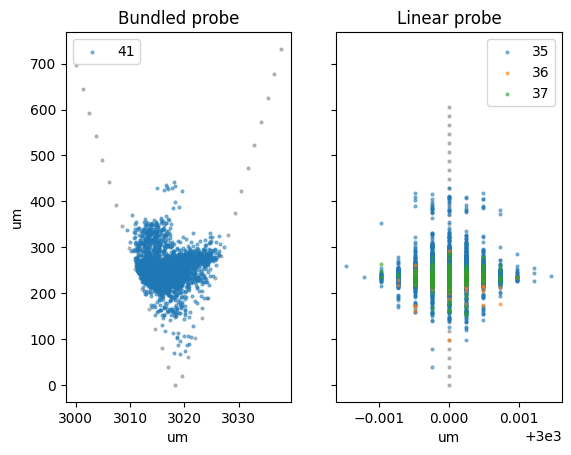

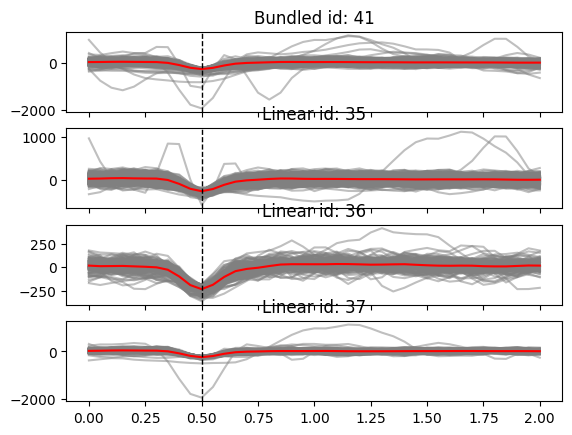

------------------------------------------------------------------------------------------
(3, 4)
[[ 0 42 45 52]
 [ 0 43 45 52]
 [ 0 44 45 52]]
Bundled unit 42: 153 spikes
Bundled unit 43: 131 spikes
Bundled unit 44: 273 spikes


C:\Users\social\AppData\Local\Temp\ipykernel_45792\3927794510.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


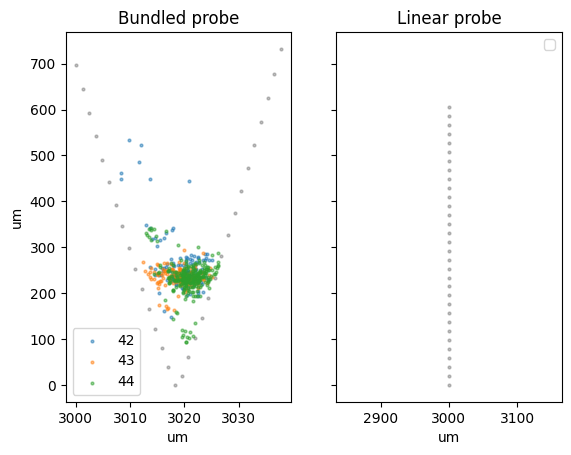

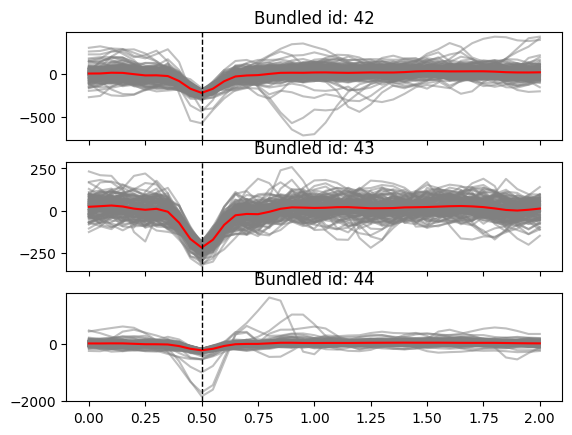

------------------------------------------------------------------------------------------
(3, 4)
[[ 0 45 39 63]
 [ 1 38 39 63]
 [ 1 39 39 63]]
Bundled unit 45: 229038 spikes
Linear unit 38: 24260 spikes
Linear unit 39: 205073 spikes


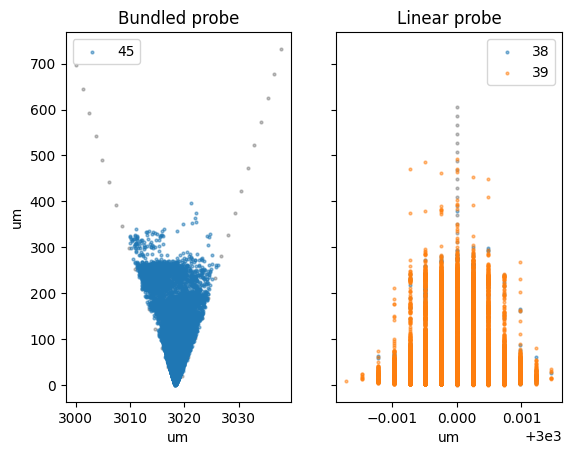

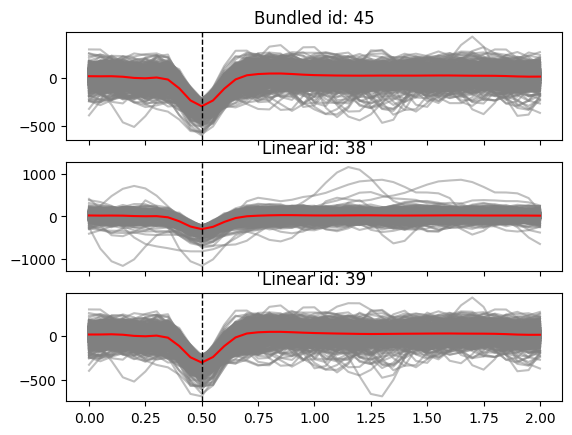

------------------------------------------------------------------------------------------


In [9]:
# for each channel with more than one unit, compare the units present based on IBL and also 
# let's first see which units have identical peak channels:

clusters = cluster_units_by_channel_radius(unit_arrays=[b_cluster_data.T, l_cluster_data.T], chan_map=siteMap_bundled, radius=0)
spikes_paths = [bundled_spikesFilt_path, linear_spikesFilt_path]
res_paths = [bundled_res_mat_path, linear_res_mat_path]
title = ['Bundled', 'Linear']

no_axes = False
for cluster in clusters:
    cluster = np.array(cluster)
    if cluster.shape[0] > 1:
        fig, axes = plt.subplots(1, 2, sharey=True)
        fig2, axes2 = plt.subplots(len(cluster), 1, sharex=True)
        if len(cluster) == 1:
            no_axes = True

        axes[0].scatter(siteLoc_bundled[32:,0], siteLoc_bundled[32:,1], color="gray", s=4, alpha=0.5)
        axes[1].scatter(siteLoc_linear[32:, 0], siteLoc_linear[32:,1], color="gray", s=4, alpha=0.5)
        axes[0].set_xlabel("um")
        axes[1].set_xlabel("um")
        axes[0].set_ylabel("um")

        axes[0].set_title("Bundled probe")
        axes[1].set_title("Linear probe")
        print(cluster.shape)
        print(cluster)
        for i, unit in enumerate(cluster):
            # extract the unit data for each cluster 
            # res_mat_path, spikesFilt_mat_path, siteMap, unit_index
            data = extract_unit_data_JRCLUST(res_mat_path=res_paths[unit[0]],spikesFilt_mat_path=spikes_paths[unit[0]], siteMap = siteMap_bundled, cluster_id=unit[1])
            print(f"{title[unit[0]]} unit {unit[1]}: {data["spike_locations"].shape[0]} spikes")
            # do some comparison ! 
            axes[unit[0]].scatter(data["spike_locations"][:, 0], data["spike_locations"][:, 1], s=4, alpha=0.5, label=str(unit[1]))
            t = np.arange(data["spike_waveforms"].shape[2]) / 20000 * 1000

            if no_axes:
                ax = axes2
            else:
                ax = axes2[i]
            ax.set_title(f'{title[unit[0]]} id: {unit[1]}')
            ax.plot(t, data["spike_waveforms"][:1000, 0, :].T, color="gray", alpha=0.5)
            ax.plot(t, np.mean(data["spike_waveforms"][:1000, 0, :], axis=0), color="red")
            ax.axvline(0.5, color='black', linestyle='--', linewidth=1)

        axes[0].legend()
        axes[1].legend()
        
        plt.show()
        print("------------------------------------------------------------------------------------------")

The two dictionaries contain all the data we need to compare the individual units:

Dict keys:
- unit_peak_chan_index
- spike_times
- spike_amplitudes
- spike_locations
- spike_waveforms

In [11]:
b_cluster_data.shape

(3, 45)

In [ ]:
from cluster_analysis import * 

# compute correlation between early and late spikes (as drift / stability metric)
# compute correlation between each spike to the mean spike 
    # mean_wf.ravel()

# compute amplitude over time in peak channel 


def compute_unit_metrics(res_mat_path, spikesFilt_path, siteMap, duration_s=3794.32):
    data = []
    clusters_data = extract_cluster_data_JRCLUST(res_mat_path, siteMap)
    
    for unit_overview_data in clusters_data:
        entry = {
            "unit_id": unit_overview_data[0],
            "peak_chan_id": unit_overview_data[1],
            "peak_chan_index": unit_overview_data[2],
        }
        
        unit_data = extract_unit_data_JRCLUST(res_mat_path=res_mat_path, spikesFilt_mat_path=spikesFilt_path, siteMap=siteMap, cluster_id=unit_overview_data[0])
        entry["num_spikes"] = len(unit_data["spikes_times"])
        entry["firing_rate_hz"] = firing_rate(unit_data["spikes_times"], duration_s)
        entry["presence_ratio"] = presence_ratio(unit_data["spikes_times"], duration_s)
        entry["isi_violations_count"] = isi_violations(unit_data["spikes_times"])
        
    return pd.DataFrame(data)




#unit = extract_unit_data_JRCLUST(res_mat_path=bundled_res_mat_path,spikesFilt_mat_path=bundled_spikesFilt_path, siteMap = siteMap_bundled, cluster_id=1)


In [12]:
unit = extract_unit_data_JRCLUST(res_mat_path=bundled_res_mat_path,spikesFilt_mat_path=bundled_spikesFilt_path, siteMap = siteMap_bundled, cluster_id=1)

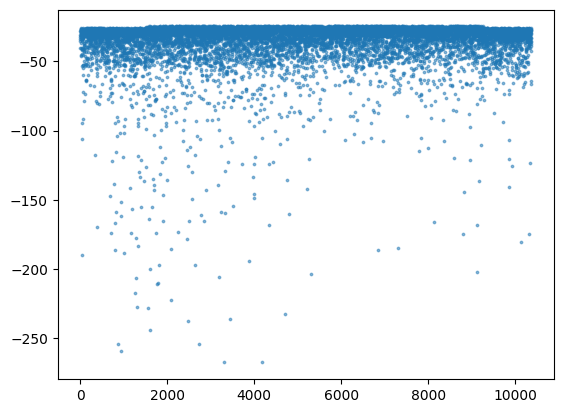

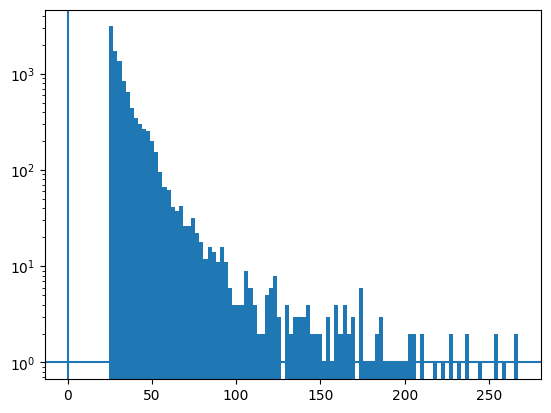

In [23]:
plt.figure()
plt.scatter(np.arange(len(unit["spike_amplitudes"])), unit["spike_amplitudes"]*0.195, s=3, alpha=0.5)
plt.show()

plt.figure()
plt.hist(np.abs(unit["spike_amplitudes"]*0.195), bins=100)
plt.axvline(0)
plt.axhline(1)
plt.yscale("log")
plt.show()

In [ ]:
unit["spike_waveforms"].shape

In [ ]:
spike_num = unit["spike_locations"].shape[0]
print(f"spikeNum: {spike_num}")

fr = firing_rate(unit["spike_times"], duration_s)
print(f"firing rate: {fr}")

pr = presence_ratio(unit["spike_times"], duration_s)
print(f"presence ratio: {pr}")

iv = isi_violations(unit["spike_times"])
print(f"ISI violations: {iv}")

#s = snr(np.mean(unit['spike_waveforms'], axis=0))

#unit_pcs = 

In [ ]:
# compute PCA per all channel blocks # shape spike_num * n_components


